In [14]:
import pandas as pd
from datetime import timedelta
import re
import numpy as np
import altair as alt

# File paths dictionary
files = {
    ('gemma-7b', 'Lab Machine'): {
        'tracker': 'LMForge_RUN03/qa_run_tracker_detailed_Lab_Machine_gemma-7b.csv',
        'results': "LMForge_RUN03/Generated_Results/gemma-7b/qa_generation_results_Lab_Machine_gemma-7b.csv",
    },
    ('gemma-7b', 'DGX Spark'): {
        'tracker': "LMForge_RUN03_DGX_SPARK_GEMMA/qa_run_tracker_detailed_DGX_Spark_gemma-7b.csv",
        'results': 'LMForge_RUN03_DGX_SPARK_GEMMA/Generated_Results/gemma-7b-spark/qa_generation_results_DGX_Spark_gemma-7b.csv',
    },
    ('microsoft-phi-4', 'Lab Machine'): {
        'tracker': "LMForge_RUN04/qa_run_tracker_detailed_Lab_Machine_microsoft_phi-4.csv",
        'results': "LMForge_RUN04/Generated_Results/microsoft_phi-4/qa_generation_results_Lab_Machine_microsoft_phi-4.csv",
    },
    ('microsoft-phi-4', 'DGX Spark'): {
        'tracker': "LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/qa_run_tracker_detailed_DGX_Spark_microsoft_phi-4.csv",
        'results': "LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/Generated_Results/microsoft-Phi-4-mini-instruct-spark/qa_generation_results_DGX_Spark_microsoft_phi-4.csv",
    },
    ('Mistral-7B-Instruct-v0.3', 'Lab Machine'): {
        'tracker': "LMForge_RUN05/qa_run_tracker_detailed_Lab_Machine_Mistral-7B-Instruct-v0.3.csv",
        'results': "LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/qa_generation_results_Lab_Machine_Mistral-7B-Instruct-v0.3.csv", 
    },
    ('Mistral-7B-Instruct-v0.3', 'DGX Spark'): {
        'tracker': "LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/qa_run_tracker_detailed_DGX_Spark_Mistral-7B-Instruct-v0.3.csv",
        'results': "LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/Generated_Results/mistralai-Mistral-7B-Instruct-v0.3-spark/qa_generation_results_DGX_Spark_Mistral-7B-Instruct-v0.3.csv", 
    },
    # Qwen data are incomplete/missing for now
}

def parse_timedelta_to_seconds(time_str):
    """Converts a time string (e.g., '2:10:46.812949' or '1 day, 5:37:59.243396') to total seconds."""
    if not isinstance(time_str, str):
        return 0

    # Remove quotes
    time_str = time_str.strip().replace('"', '')

    days = 0
    
    # Pattern 1: "X days, H:M:S.ms" or "X day, H:M:S.ms"
    day_match = re.match(r'(\d+)\s+days?,\s*(\d{1,2}):(\d{2}):(\d{2}\.\d+)', time_str)
    if day_match:
        days, hours, minutes, seconds = map(float, day_match.groups())
    else:
        # Pattern 2: "H:M:S.ms"
        time_parts = time_str.split(':')
        if len(time_parts) == 3:
            try:
                hours, minutes, seconds = map(float, time_parts)
            except ValueError:
                return 0
        elif len(time_parts) == 4:
            # Pattern 3: "D:H:M:S.ms" (if it's a non-standard timedelta string)
            try:
                days, hours, minutes, seconds = map(float, time_parts)
            except ValueError:
                return 0
        elif time_str.strip() == '0' or not time_str.strip():
            return 0
        else:
             # Try parsing as simple seconds (unlikely but robust)
            try:
                return float(time_str)
            except:
                return 0
                
    total_seconds = (days * 24 * 3600) + (hours * 3600) + (minutes * 60) + seconds
    return total_seconds

# List to hold all processed DataFrames
all_data = []

# Process each pair of files
for (model, machine), path_info in files.items():
    tracker_file = path_info['tracker']
    results_file = path_info['results']

    try:
        df_tracker = pd.read_csv(tracker_file)
        df_tracker.drop(columns=['elapsed_time'], errors='ignore', inplace=True) 

        if results_file and pd.notna(results_file):
            # 1. Process the results file for max elapsed time
            df_results = pd.read_csv(results_file)
            
            # The 'elapsed_time' column can be mixed type, so convert to string first
            df_results['elapsed_time'] = df_results['elapsed_time'].astype(str)
            df_results['elapsed_time_sec'] = df_results['elapsed_time'].apply(parse_timedelta_to_seconds)

            # Group by chunk_size and max_tokens and find the maximum elapsed time
            # Only consider rows where elapsed_time_sec > 0
            df_results_valid_time = df_results[df_results['elapsed_time_sec'] > 0]
            df_time = df_results_valid_time.groupby(['chunk_size', 'max_tokens'])['elapsed_time_sec'].max().reset_index()
            
            # 2. Merge time back into the tracker file
            df_merged = pd.merge(df_tracker, df_time, on=['chunk_size', 'max_tokens'], how='left')
        else:
            # If results file is missing, use tracker data and fill time with NaN
            df_merged = df_tracker
            df_merged['elapsed_time_sec'] = np.nan

        # 3. Calculate new metrics
        df_merged['Machine'] = machine
        df_merged['Model'] = model
        
        # Ensure total_questions is numeric before division
        df_merged['total_questions'] = pd.to_numeric(df_merged['total_questions'], errors='coerce').fillna(0)
        
        # Questions per Second (Throughput)
        # Handle division by zero/NaN for elapsed time
        df_merged['questions_per_sec'] = df_merged.apply(
            lambda row: row['total_questions'] / row['elapsed_time_sec'] if row['elapsed_time_sec'] > 0 else 0, 
            axis=1
        )
        
        # Success Rate (as a proxy for successful chunk processing)
        df_merged['success_count'] = pd.to_numeric(df_merged['success_count'], errors='coerce').fillna(0)
        df_merged['total_chunks'] = pd.to_numeric(df_merged['total_chunks'], errors='coerce').fillna(0)
        
        df_merged['success_rate'] = df_merged.apply(
            lambda row: (row['success_count'] / row['total_chunks']) if row['total_chunks'] > 0 else 0, 
            axis=1
        )

        # Append to the list
        all_data.append(df_merged)

    except FileNotFoundError:
        print(f"Error: One or more files for {model} on {machine} not found.")
    except Exception as e:
        print(f"An unexpected error occurred for {model} on {machine}: {e}")

# Concatenate all data into a single DataFrame
df_master = pd.concat(all_data, ignore_index=True)

# Final cleanup: Remove rows where elapsed_time_sec is NaN or less than or equal to 0, as they are not valid full run measurements.
df_master.replace([float('inf'), float('-inf')], np.nan, inplace=True)
df_master = df_master[df_master['elapsed_time_sec'].gt(0) & df_master['elapsed_time_sec'].notna()]
df_master.reset_index(drop=True, inplace=True)

# Save the master DataFrame to a CSV for user access and further analysis
master_csv_file = "Plots_And_Results/llm_performance_comparison_master.csv"
df_master.to_csv(master_csv_file, index=False)

print(f"Master performance data saved to {master_csv_file}")
print("Data head:")
print(df_master.head())
print("\nData info:")
print(df_master.info())

# --- Plotting Code (using the generated master CSV) ---

df = pd.read_csv("Plots_And_Results/llm_performance_comparison_master.csv")

# Ensure 'chunk_size' is treated as categorical for faceting
df['chunk_size'] = df['chunk_size'].astype(str)

# Plot 1: Elapsed Time vs. Max Tokens
base_time = alt.Chart(df).encode(
    x=alt.X('max_tokens:O', title='Max Tokens', sort='ascending'),
    tooltip=[
        'chunk_size', 
        'max_tokens', 
        alt.Tooltip('elapsed_time_sec', title='Time (s)', format='.1f'),
        'Machine', 
        'Model'
    ]
).properties(
    title='Elapsed Time (seconds) vs. Max Tokens'
)

chart_time = base_time.mark_line(point=True).encode(
    y=alt.Y('elapsed_time_sec', title='Elapsed Time (seconds)'),
    color=alt.Color('Machine', title='Machine'), 
    strokeDash=alt.StrokeDash('chunk_size', title='Chunk Size')
).facet(
    column=alt.Column('Model', header=alt.Header(titleOrient="bottom", labelOrient="bottom"), sort=['gemma-7b', 'microsoft-phi-4', 'Mistral-7B-Instruct-v0.3']),
    row=alt.Row('chunk_size', title='Chunk Size', header=alt.Header(titleOrient="right", labelOrient="right")) 
).resolve_scale(
    y='independent'
)

chart_time.save('Plots_And_Results/elapsed_time_vs_max_tokens.json')


# Plot 2: Questions per Second vs. Max Tokens (Throughput)
base_qps = alt.Chart(df).encode(
    x=alt.X('max_tokens:O', title='Max Tokens', sort='ascending'),
    tooltip=[
        'chunk_size', 
        'max_tokens', 
        alt.Tooltip('questions_per_sec', title='Q/s', format='.2f'),
        'Machine', 
        'Model'
    ]
).properties(
    title='Throughput (Questions/Second) vs. Max Tokens'
)

chart_qps = base_qps.mark_line(point=True).encode(
    y=alt.Y('questions_per_sec', title='Questions per Second'),
    color=alt.Color('Machine', title='Machine'),
    strokeDash=alt.StrokeDash('chunk_size', title='Chunk Size')
).facet(
    column=alt.Column('Model', header=alt.Header(titleOrient="bottom", labelOrient="bottom"), sort=['gemma-7b', 'microsoft-phi-4', 'Mistral-7B-Instruct-v0.3']),
    row=alt.Row('chunk_size', title='Chunk Size', header=alt.Header(titleOrient="right", labelOrient="right"))
).resolve_scale(
    y='independent'
)

chart_qps.save('Plots_And_Results/questions_per_sec_vs_max_tokens.json')


# Plot 3: Success Rate vs. Max Tokens
base_success = alt.Chart(df).encode(
    x=alt.X('max_tokens:O', title='Max Tokens', sort='ascending'),
    tooltip=[
        'chunk_size', 
        'max_tokens', 
        alt.Tooltip('success_rate', title='Success Rate', format='.1%'),
        'Machine', 
        'Model'
    ]
).properties(
    title='Success Rate vs. Max Tokens'
)

chart_success = base_success.mark_line(point=True).encode(
    y=alt.Y('success_rate', title='Success Rate (Success Count / Total Chunks)', axis=alt.Axis(format='%')),
    color=alt.Color('Machine', title='Machine'),
    strokeDash=alt.StrokeDash('chunk_size', title='Chunk Size')
).facet(
    column=alt.Column('Model', header=alt.Header(titleOrient="bottom", labelOrient="bottom"), sort=['gemma-7b', 'microsoft-phi-4', 'Mistral-7B-Instruct-v0.3']),
    row=alt.Row('chunk_size', title='Chunk Size', header=alt.Header(titleOrient="right", labelOrient="right"))
).resolve_scale(
    y='independent'
)

chart_success.save('Plots_And_Results/success_rate_vs_max_tokens.json')

Master performance data saved to Plots_And_Results/llm_performance_comparison_master.csv
Data head:
   chunk_size  questions_num  qa_count_mismatch  total_questions  max_tokens  \
0         128              0                  3             1625         128   
1         128              0                 11             2268         256   
2         128              0                 15             2492         512   
3         128              0                 16             2504        1024   
4         128              0                 16             2504        2048   

   total_chunks  success_count  fail_count  repeat_count  duplicate_count  \
0          1800            811         989             0               16   
1          1800           1127         673             2               20   
2          1800           1233         567             4               20   
3          1800           1237         563             4               20   
4          1800           1237    

Saved performance_plots.png
Saved accuracy_plots.png


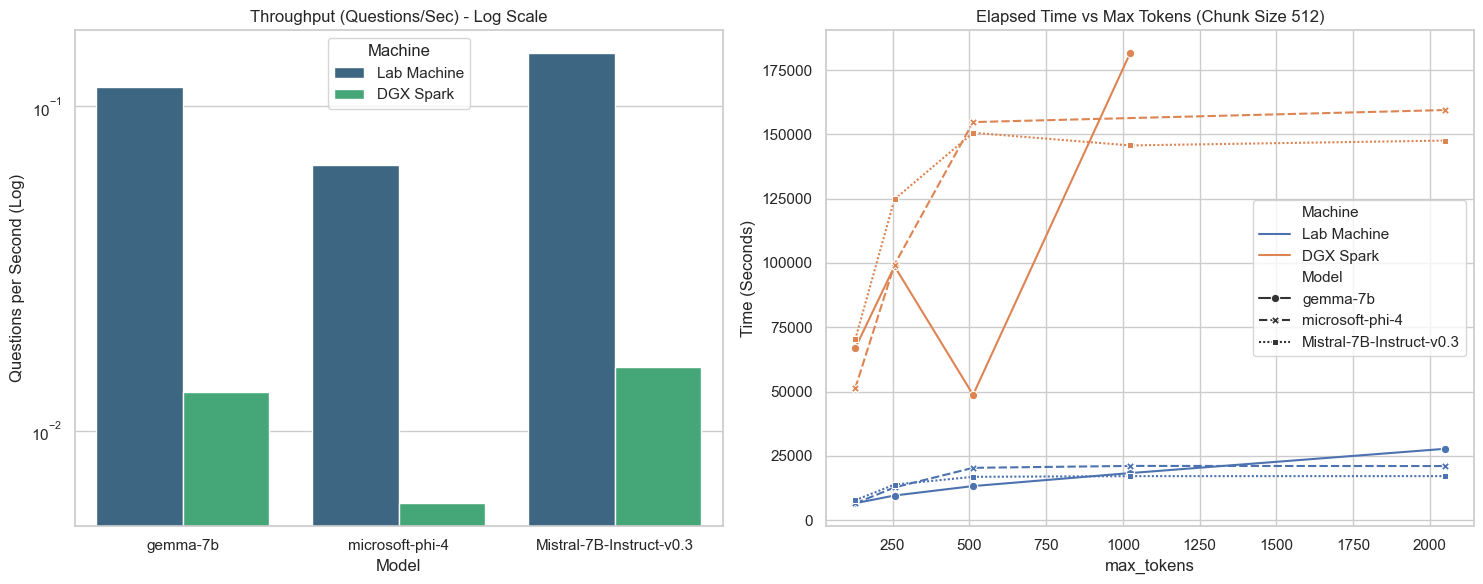

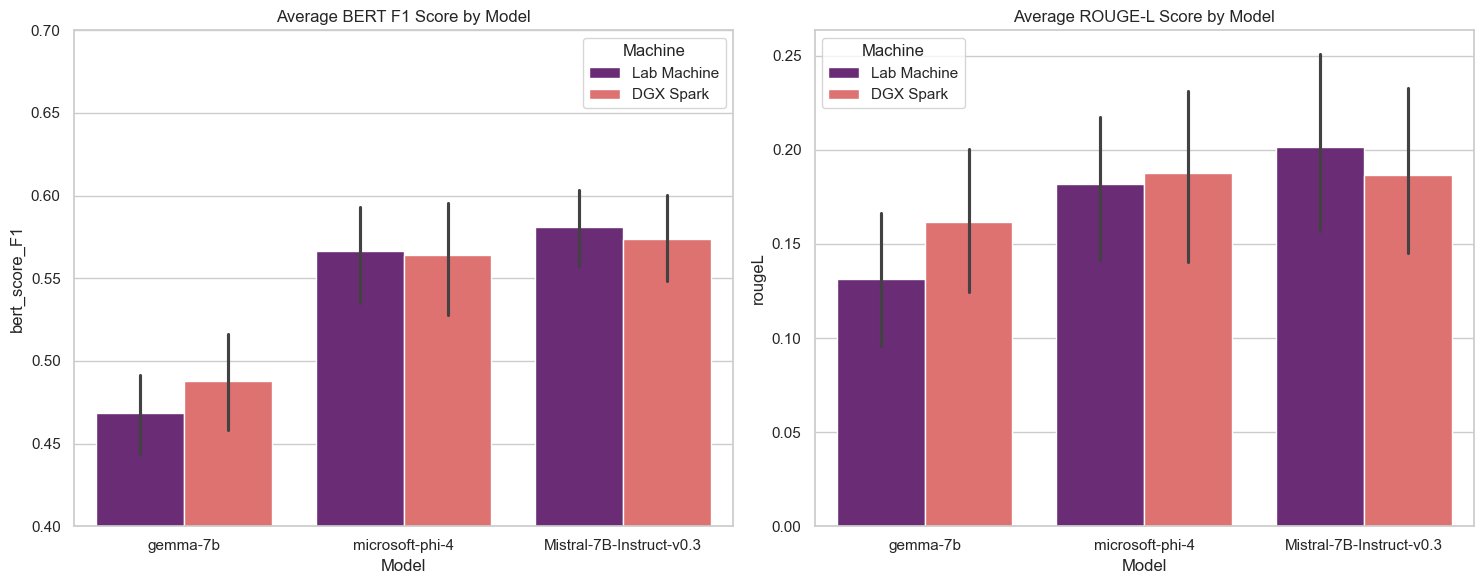

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np

# --- Configuration ---
# Update these filenames if they differ on your disk

FILES = {
    'perf': [
        ('gemma-7b', 'Lab Machine', 'LMForge_RUN03/qa_run_tracker_detailed_Lab_Machine_gemma-7b.csv', 'LMForge_RUN03/Generated_Results/gemma-7b/qa_generation_results_Lab_Machine_gemma-7b.csv'),
        ('gemma-7b', 'DGX Spark', 'LMForge_RUN03_DGX_SPARK_GEMMA/qa_run_tracker_detailed_DGX_Spark_gemma-7b.csv', 'LMForge_RUN03_DGX_SPARK_GEMMA/Generated_Results/gemma-7b-spark/qa_generation_results_DGX_Spark_gemma-7b.csv'),
        ('microsoft-phi-4', 'Lab Machine', 'LMForge_RUN04/qa_run_tracker_detailed_Lab_Machine_microsoft_phi-4.csv', 'LMForge_RUN04/Generated_Results/microsoft_phi-4/qa_generation_results_Lab_Machine_microsoft_phi-4.csv'),
        ('microsoft-phi-4', 'DGX Spark', 'LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/qa_run_tracker_detailed_DGX_Spark_microsoft_phi-4.csv', 'LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/Generated_Results/microsoft-Phi-4-mini-instruct-spark/qa_generation_results_DGX_Spark_microsoft_phi-4.csv'),
        ('Mistral-7B-Instruct-v0.3', 'Lab Machine', 'LMForge_RUN05/qa_run_tracker_detailed_Lab_Machine_Mistral-7B-Instruct-v0.3.csv', 'LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/qa_generation_results_Lab_Machine_Mistral-7B-Instruct-v0.3.csv'),
        ('Mistral-7B-Instruct-v0.3', 'DGX Spark', 'LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/qa_run_tracker_detailed_DGX_Spark_Mistral-7B-Instruct-v0.3.csv', 'LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/Generated_Results/mistralai-Mistral-7B-Instruct-v0.3-spark/qa_generation_results_DGX_Spark_Mistral-7B-Instruct-v0.3.csv'),
    ],
    'scores': [
        ('gemma-7b', 'Lab Machine', 'LMForge_RUN03/Generated_Results/gemma-7b/scores_Lab_Machine_gemma-7b.csv'),
        ('gemma-7b', 'DGX Spark', 'LMForge_RUN03_DGX_SPARK_GEMMA/Generated_Results/gemma-7b-spark/scores_DGX_Spark_gemma-7b.csv'),
        ('microsoft-phi-4', 'Lab Machine', 'LMForge_RUN04/Generated_Results/microsoft_phi-4/scores_Lab_Machine_microsoft_phi-4.csv'),
        ('microsoft-phi-4', 'DGX Spark', 'LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/Generated_Results/microsoft-Phi-4-mini-instruct-spark/scores_DGX_Spark_microsoft_phi-4.csv'),
        ('Mistral-7B-Instruct-v0.3', 'Lab Machine', 'LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/scores_Lab_Machine_Mistral-7B-Instruct-v0.3.csv'),
        ('Mistral-7B-Instruct-v0.3', 'DGX Spark', 'LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/Generated_Results/mistralai-Mistral-7B-Instruct-v0.3-spark/scores_DGX_Spark_Mistral-7B-Instruct-v0.3.csv'),
    ]
}

def parse_time(time_str):
    """Parses time strings like '1 day, 5:30:00.00' into seconds."""
    if not isinstance(time_str, str): return 0
    time_str = time_str.strip().replace('"', '')
    try:
        if 'day' in time_str:
            day_part, time_part = time_str.split(',')
            days = float(day_part.split()[0])
            h, m, s = map(float, time_part.strip().split(':'))
            return (days * 86400) + (h * 3600) + (m * 60) + s
        elif ':' in time_str:
            parts = list(map(float, time_str.split(':')))
            if len(parts) == 3: return parts[0]*3600 + parts[1]*60 + parts[2]
    except: pass
    return 0

# --- Data Loading ---
perf_data = []
for model, machine, tracker_f, results_f in FILES['perf']:
    try:
        # Load Tracker
        df_t = pd.read_csv(tracker_f)
        if 'elapsed_time' in df_t.columns: df_t = df_t.drop(columns=['elapsed_time'])
        
        # Load Results (for Time)
        df_r = pd.read_csv(results_f)
        df_r['elapsed_time_sec'] = df_r['elapsed_time'].astype(str).apply(parse_time)
        
        # Get max time per config to avoid partial run noise
        df_time = df_r[df_r['elapsed_time_sec'] > 1.0].groupby(['chunk_size', 'max_tokens'])['elapsed_time_sec'].max().reset_index()
        
        # Merge
        df = pd.merge(df_t, df_time, on=['chunk_size', 'max_tokens'], how='inner')
        df['Model'] = model
        df['Machine'] = machine
        
        # Calculate Throughput
        df['total_questions'] = pd.to_numeric(df['total_questions'], errors='coerce').fillna(0)
        df['throughput'] = df['total_questions'] / df['elapsed_time_sec']
        perf_data.append(df)
    except FileNotFoundError: print(f"Warning: File not found for {model} {machine}")

df_perf = pd.concat(perf_data, ignore_index=True)

score_data = []
for model, machine, score_f in FILES['scores']:
    try:
        df = pd.read_csv(score_f)
        df['Model'] = model
        df['Machine'] = machine
        score_data.append(df)
    except FileNotFoundError: print(f"Warning: File not found for {model} {machine}")

df_scores = pd.concat(score_data, ignore_index=True)

# --- Plotting ---
sns.set_theme(style="whitegrid")

# 1. Performance Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Throughput Comparison (Log Scale due to large differences)
sns.barplot(data=df_perf, x='Model', y='throughput', hue='Machine', errorbar=None, ax=axes[0], palette="viridis")
axes[0].set_yscale('log')
axes[0].set_title('Throughput (Questions/Sec) - Log Scale')
axes[0].set_ylabel('Questions per Second (Log)')

# Plot B: Time vs Max Tokens (for Chunk Size 512)
subset_512 = df_perf[df_perf['chunk_size'] == 512]
sns.lineplot(data=subset_512, x='max_tokens', y='elapsed_time_sec', hue='Machine', style='Model', markers=True, ax=axes[1])
axes[1].set_title('Elapsed Time vs Max Tokens (Chunk Size 512)')
axes[1].set_ylabel('Time (Seconds)')

plt.tight_layout()
plt.savefig('Plots_And_Results/performance_plots.png')
print("Saved performance_plots.png")

# 2. Accuracy Plots
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))

# Plot C: BERT Score Comparison
sns.barplot(data=df_scores, x='Model', y='bert_score_F1', hue='Machine', ax=axes2[0], palette="magma")
axes2[0].set_ylim(0.4, 0.7) # Zoom in on relevant range
axes2[0].set_title('Average BERT F1 Score by Model')

# Plot D: ROUGE-L Comparison
sns.barplot(data=df_scores, x='Model', y='rougeL', hue='Machine', ax=axes2[1], palette="magma")
axes2[1].set_title('Average ROUGE-L Score by Model')

plt.tight_layout()
plt.savefig('Plots_And_Results/accuracy_plots.png')
print("Saved accuracy_plots.png")

--- Processing Performance Files ---
Rows before filter: 113
Rows after filtering chunk_size <= 512: 90

--- DEBUG: Check Time Parsing ---
       Model  chunk_size  max_tokens  total_questions  elapsed_time_sec  \
20  gemma-7b         128         128             1616      63003.417661   
21  gemma-7b         128         256             2278     106679.243396   
22  gemma-7b         128         512             1115      77767.547990   
23  gemma-7b         128        1024             1123     111455.096417   
24  gemma-7b         128        2048             2509     322180.108492   
25  gemma-7b         256         128             1152      76914.665440   
26  gemma-7b         256         256             1337               NaN   
27  gemma-7b         256         512             2068     154229.020206   
28  gemma-7b         256        1024             2110     207219.442466   
29  gemma-7b         256        2048             2112     305783.412977   

    throughput  
20    0.025649  
2

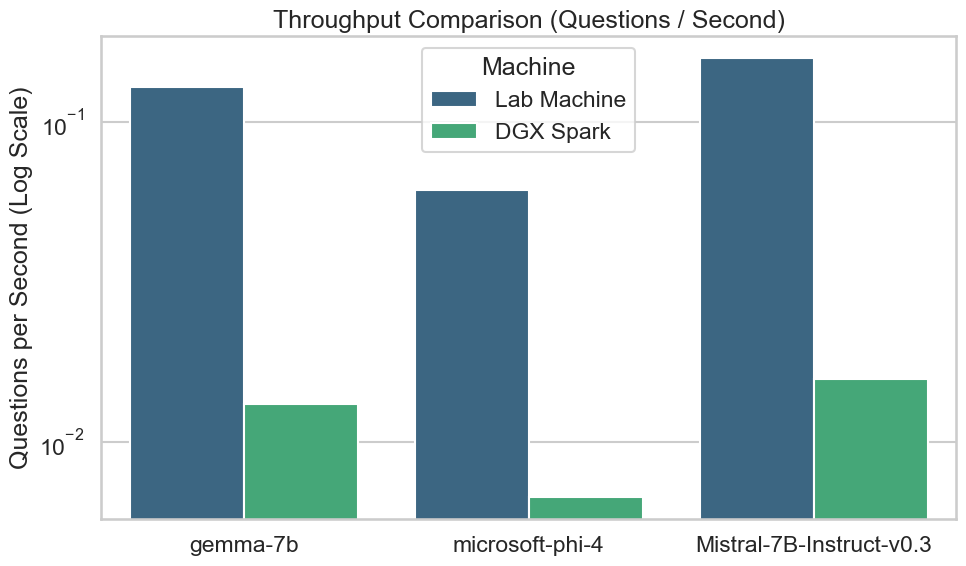

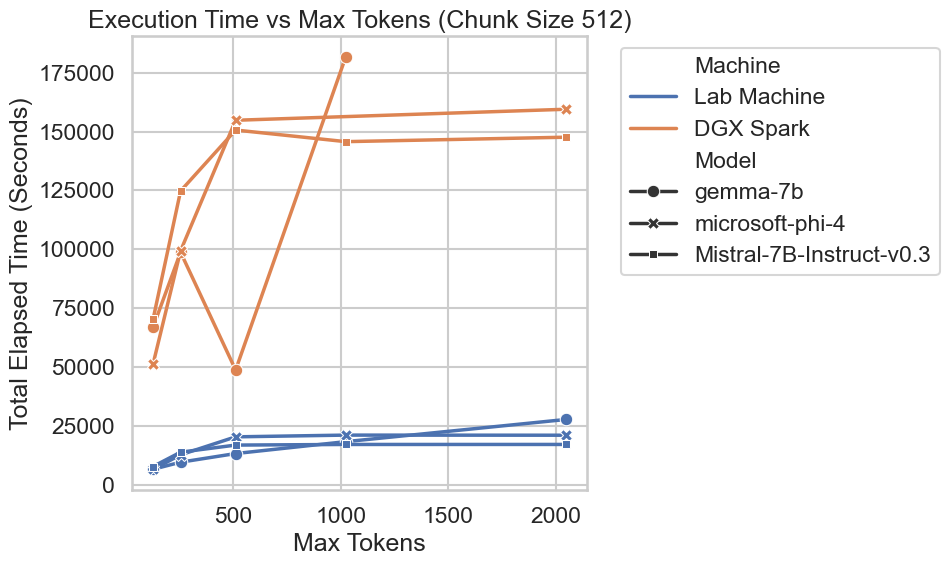

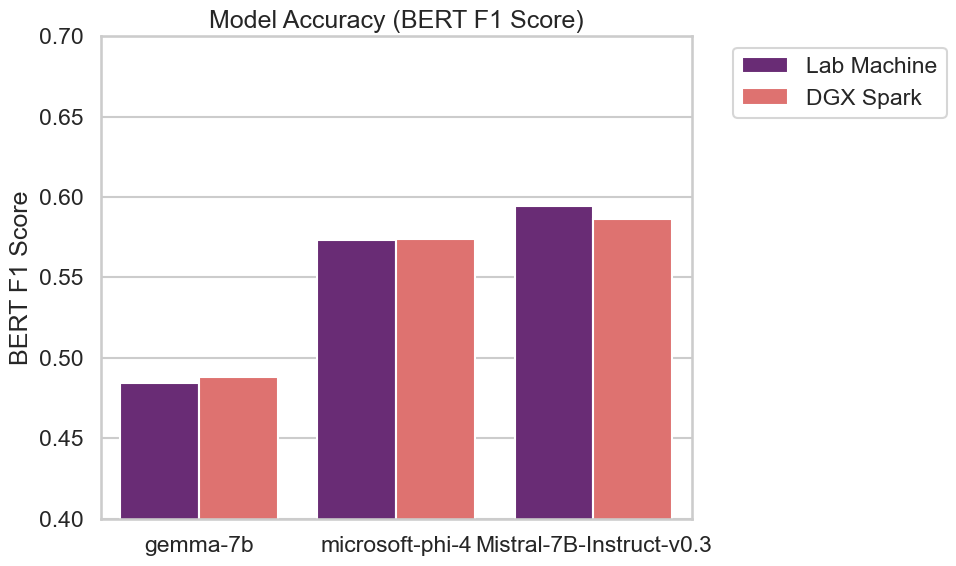


Processing Complete. Plots saved to 'Plots_And_Results/' folder.


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np
import os

# --- 1. Configuration & File Paths ---
# Ensure these paths point to the correct locations on your machine
FILES = {
    'perf': [
        ('gemma-7b', 'Lab Machine', 'LMForge_RUN03/qa_run_tracker_detailed_Lab_Machine_gemma-7b.csv', 'LMForge_RUN03/Generated_Results/gemma-7b/qa_generation_results_Lab_Machine_gemma-7b.csv'),
        ('gemma-7b', 'DGX Spark', 'LMForge_RUN03_DGX_SPARK_GEMMA/qa_run_tracker_detailed_DGX_Spark_gemma-7b.csv', 'LMForge_RUN03_DGX_SPARK_GEMMA/Generated_Results/gemma-7b-spark/qa_generation_results_DGX_Spark_gemma-7b.csv'),
        ('microsoft-phi-4', 'Lab Machine', 'LMForge_RUN04/qa_run_tracker_detailed_Lab_Machine_microsoft_phi-4.csv', 'LMForge_RUN04/Generated_Results/microsoft_phi-4/qa_generation_results_Lab_Machine_microsoft_phi-4.csv'),
        ('microsoft-phi-4', 'DGX Spark', 'LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/qa_run_tracker_detailed_DGX_Spark_microsoft_phi-4.csv', 'LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/Generated_Results/microsoft-Phi-4-mini-instruct-spark/qa_generation_results_DGX_Spark_microsoft_phi-4.csv'),
        ('Mistral-7B-Instruct-v0.3', 'Lab Machine', 'LMForge_RUN05/qa_run_tracker_detailed_Lab_Machine_Mistral-7B-Instruct-v0.3.csv', 'LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/qa_generation_results_Lab_Machine_Mistral-7B-Instruct-v0.3.csv'),
        ('Mistral-7B-Instruct-v0.3', 'DGX Spark', 'LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/qa_run_tracker_detailed_DGX_Spark_Mistral-7B-Instruct-v0.3.csv', 'LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/Generated_Results/mistralai-Mistral-7B-Instruct-v0.3-spark/qa_generation_results_DGX_Spark_Mistral-7B-Instruct-v0.3.csv'),
    ],
    'scores': [
        ('gemma-7b', 'Lab Machine', 'LMForge_RUN03/Generated_Results/gemma-7b/scores_Lab_Machine_gemma-7b.csv'),
        ('gemma-7b', 'DGX Spark', 'LMForge_RUN03_DGX_SPARK_GEMMA/Generated_Results/gemma-7b-spark/scores_DGX_Spark_gemma-7b.csv'),
        ('microsoft-phi-4', 'Lab Machine', 'LMForge_RUN04/Generated_Results/microsoft_phi-4/scores_Lab_Machine_microsoft_phi-4.csv'),
        ('microsoft-phi-4', 'DGX Spark', 'LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/Generated_Results/microsoft-Phi-4-mini-instruct-spark/scores_DGX_Spark_microsoft_phi-4.csv'),
        ('Mistral-7B-Instruct-v0.3', 'Lab Machine', 'LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/scores_Lab_Machine_Mistral-7B-Instruct-v0.3.csv'),
        ('Mistral-7B-Instruct-v0.3', 'DGX Spark', 'LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/Generated_Results/mistralai-Mistral-7B-Instruct-v0.3-spark/scores_DGX_Spark_Mistral-7B-Instruct-v0.3.csv'),
    ]
}

# --- 2. Robust Time Parsing Function ---
def parse_time_robust(time_str):
    """
    Parses time strings into total seconds.
    Handles formats:
    - "1 day, 5:30:00.123"
    - "1 day, 5:30:00" (no ms)
    - "05:30:00.123"
    - "05:30:00"
    """
    if not isinstance(time_str, str): 
        return 0.0
    
    # Clean string
    time_str = time_str.strip().replace('"', '').replace("'", "")
    
    try:
        days = 0.0
        # Check for "day" or "days"
        if 'day' in time_str:
            parts = time_str.split(',')
            # part[0] is like "1 day"
            days = float(parts[0].split()[0])
            # part[1] is like " 5:30:00.123"
            time_part = parts[1].strip()
        else:
            time_part = time_str.strip()

        # Split H:M:S
        time_components = time_part.split(':')
        hours = float(time_components[0])
        minutes = float(time_components[1])
        seconds = float(time_components[2])
        
        total_seconds = (days * 86400) + (hours * 3600) + (minutes * 60) + seconds
        return total_seconds

    except Exception as e:
        # unexpected format, return 0 so it can be filtered out
        return 0.0

# --- 3. Data Processing ---
perf_data = []

print("--- Processing Performance Files ---")
for model, machine, tracker_f, results_f in FILES['perf']:
    try:
        # Load Tracker (Counts)
        df_t = pd.read_csv(tracker_f)
        # Drop elapsed_time from tracker if it exists, as we want the one from results
        if 'elapsed_time' in df_t.columns: 
            df_t = df_t.drop(columns=['elapsed_time'])
        
        # Load Results (Timing)
        if os.path.exists(results_f):
            df_r = pd.read_csv(results_f)
            df_r['elapsed_time_sec'] = df_r['elapsed_time'].astype(str).apply(parse_time_robust)
            
            # CRITICAL: Pick the longest time recorded for each config to avoid partial run noise
            # We filter for > 10 seconds to avoid "start-up" logs
            df_time = df_r[df_r['elapsed_time_sec'] > 10].groupby(['chunk_size', 'max_tokens'])['elapsed_time_sec'].max().reset_index()
            
            # Merge Tracker and Time
            df = pd.merge(df_t, df_time, on=['chunk_size', 'max_tokens'], how='left')
        else:
            print(f"  [Warn] Result file missing for {model} {machine}")
            df = df_t
            df['elapsed_time_sec'] = np.nan

        df['Model'] = model
        df['Machine'] = machine
        
        # Metrics
        df['total_questions'] = pd.to_numeric(df['total_questions'], errors='coerce').fillna(0)
        # Calculate Q/S only if we have valid time
        df['throughput'] = df.apply(
            lambda x: x['total_questions'] / x['elapsed_time_sec'] if (pd.notnull(x['elapsed_time_sec']) and x['elapsed_time_sec'] > 0) else 0, 
            axis=1
        )
        
        # Calculate Success Rate
        df['success_count'] = pd.to_numeric(df['success_count'], errors='coerce').fillna(0)
        df['total_chunks'] = pd.to_numeric(df['total_chunks'], errors='coerce').fillna(0)
        df['success_rate'] = df.apply(lambda x: x['success_count'] / x['total_chunks'] if x['total_chunks'] > 0 else 0, axis=1)

        perf_data.append(df)
        
    except Exception as e:
        print(f"  [Error] Failed processing {model} {machine}: {e}")

# Combine Data
df_perf = pd.concat(perf_data, ignore_index=True)

# --- 4. Filtering (User Request: Ignore 1024 chunk size) ---
print(f"Rows before filter: {len(df_perf)}")
df_perf = df_perf[df_perf['chunk_size'] <= 512]
print(f"Rows after filtering chunk_size <= 512: {len(df_perf)}")

# --- 5. Scores Loading ---
score_data = []
for model, machine, score_f in FILES['scores']:
    try:
        if os.path.exists(score_f):
            df = pd.read_csv(score_f)
            df['Model'] = model
            df['Machine'] = machine
            # Also filter scores
            df = df[df['chunk_size'] <= 512]
            score_data.append(df)
    except:
        pass
df_scores = pd.concat(score_data, ignore_index=True)

# --- 6. DEBUG: Check for the "DGX Faster" Error ---
print("\n--- DEBUG: Check Time Parsing ---")
# Show a few examples of DGX data to verify time is large (e.g. > 50000 seconds)
debug_view = df_perf[df_perf['Machine'] == 'DGX Spark'][['Model', 'chunk_size', 'max_tokens', 'total_questions', 'elapsed_time_sec', 'throughput']]
print(debug_view.head(10))
# If 'elapsed_time_sec' is small (< 3600) for a full run, the parser or file mapping is wrong.

# --- 7. Plotting (Seaborn for Reports) ---
sns.set_theme(style="whitegrid", context="talk") # 'talk' makes fonts larger for reports

# Plot A: Throughput (Speed)
plt.figure(figsize=(10, 6))
# Filter out 0 throughput for cleaner plot
plot_data_perf = df_perf[df_perf['throughput'] > 0]
sns.barplot(data=plot_data_perf, x='Model', y='throughput', hue='Machine', palette='viridis', errorbar=None)
plt.yscale('log') # Log scale because Lab might be 10x faster
plt.title('Throughput Comparison (Questions / Second)')
plt.ylabel('Questions per Second (Log Scale)')
plt.xlabel('')
plt.legend(title='Machine')
plt.tight_layout()
plt.savefig('Plots_And_Results/report_throughput.png')
plt.show()

# Plot B: Elapsed Time Scaling (Efficiency)
# We pick a specific chunk size (e.g., 512) to see how tokens affect time
plt.figure(figsize=(10, 6))
subset_512 = df_perf[df_perf['chunk_size'] == 512]
sns.lineplot(data=subset_512, x='max_tokens', y='elapsed_time_sec', hue='Machine', style='Model', markers=True, dashes=False, linewidth=2.5)
plt.title('Execution Time vs Max Tokens (Chunk Size 512)')
plt.ylabel('Total Elapsed Time (Seconds)')
plt.xlabel('Max Tokens')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Plots_And_Results/report_time_scaling.png')
plt.show()

# Plot C: Accuracy (BERT F1)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_scores, x='Model', y='bert_score_F1', hue='Machine', palette='magma', errorbar=None)
plt.ylim(0.4, 0.7) # Zoom in to see differences
plt.title('Model Accuracy (BERT F1 Score)')
plt.ylabel('BERT F1 Score')
plt.xlabel('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Plots_And_Results/report_accuracy.png')
plt.show()

print("\nProcessing Complete. Plots saved to 'Plots_And_Results/' folder.")

Starting Data Processing...
Processing Complete. Data filtered for chunk_size=512.
Master CSV saved to Plots_And_Results/master_performance_data_512.csv


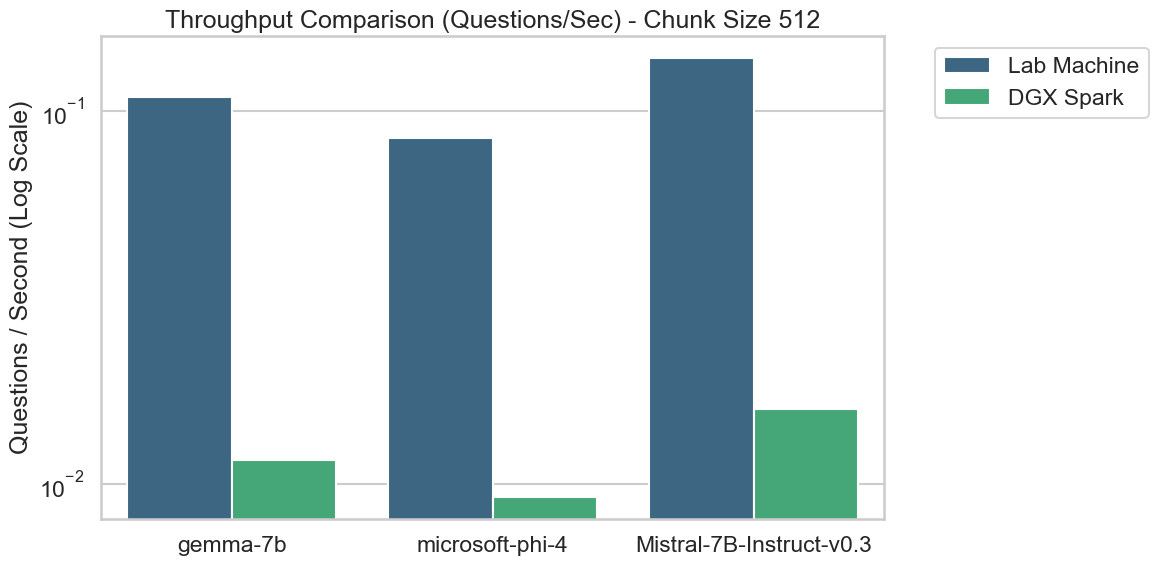

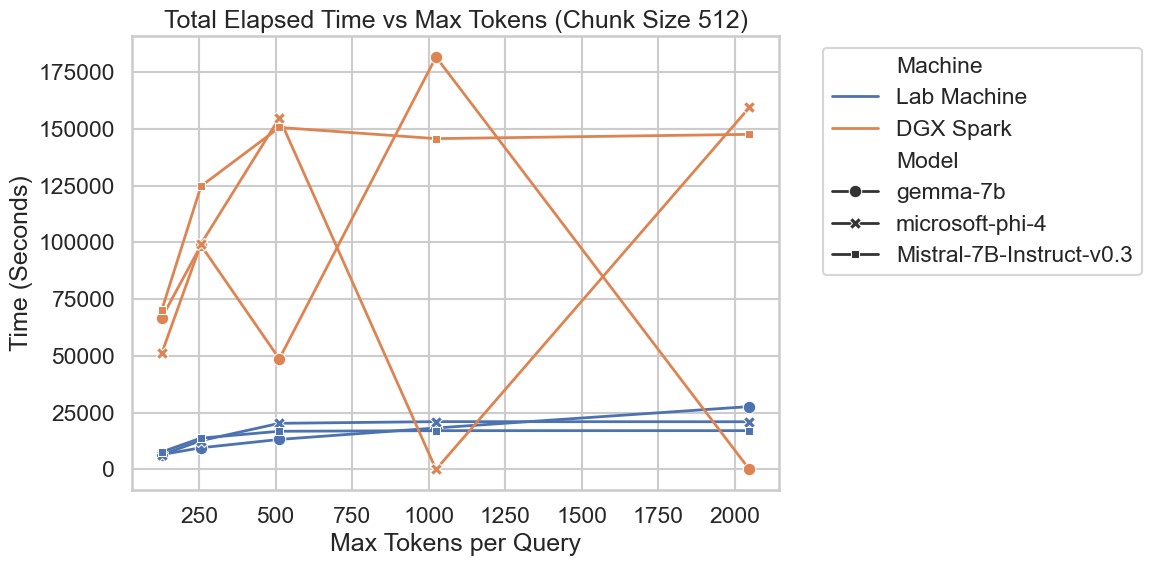

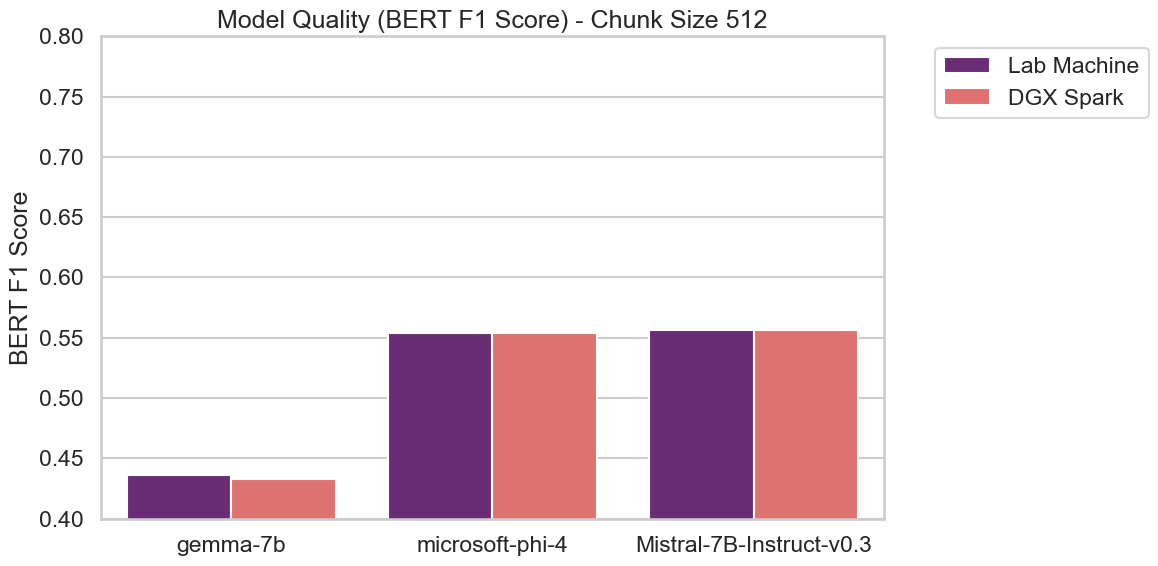

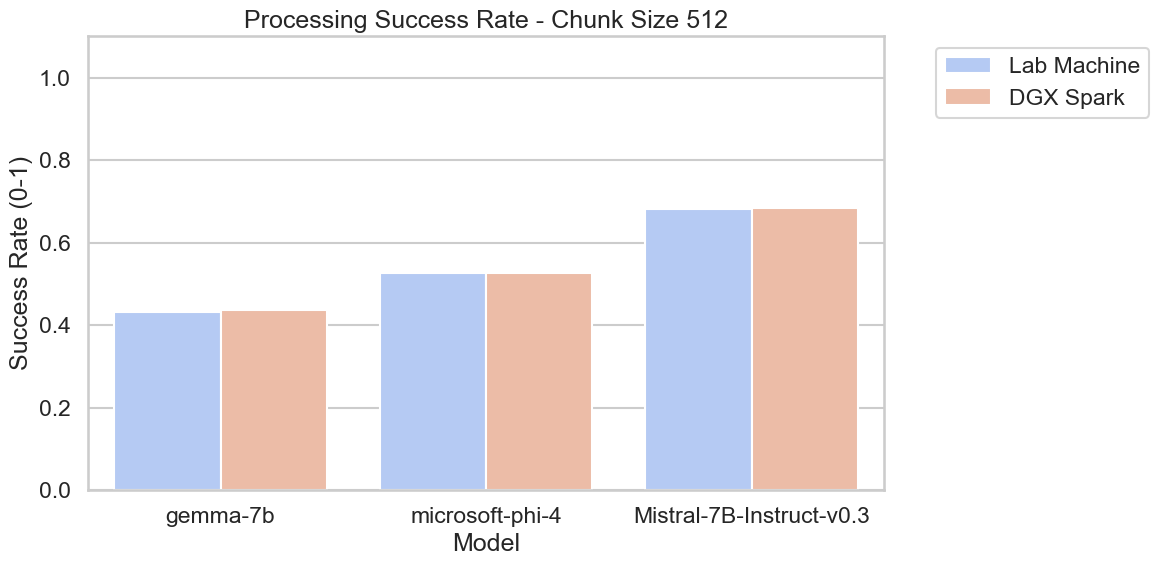

All plots saved.


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import os

# ==========================================
# 1. Configuration & File Paths
# ==========================================

# Output directory for plots
OUTPUT_DIR = "Plots_And_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# File Paths Dictionary
# Structure: (Model, Machine) -> { 'tracker': path, 'results': path, 'scores': path }
FILES = {
    ('gemma-7b', 'Lab Machine'): {
        'tracker': 'LMForge_RUN03/qa_run_tracker_detailed_Lab_Machine_gemma-7b.csv',
        'results': "LMForge_RUN03/Generated_Results/gemma-7b/qa_generation_results_Lab_Machine_gemma-7b.csv",
        'scores': "LMForge_RUN03/Generated_Results/gemma-7b/scores_Lab_Machine_gemma-7b.csv"
    },
    ('gemma-7b', 'DGX Spark'): {
        'tracker': "LMForge_RUN03_DGX_SPARK_GEMMA/qa_run_tracker_detailed_DGX_Spark_gemma-7b.csv",
        'results': 'LMForge_RUN03_DGX_SPARK_GEMMA/Generated_Results/gemma-7b-spark/qa_generation_results_DGX_Spark_gemma-7b.csv',
        'scores': "LMForge_RUN03_DGX_SPARK_GEMMA/Generated_Results/gemma-7b-spark/scores_DGX_Spark_gemma-7b.csv"
    },
    ('microsoft-phi-4', 'Lab Machine'): {
        'tracker': "LMForge_RUN04/qa_run_tracker_detailed_Lab_Machine_microsoft_phi-4.csv",
        'results': "LMForge_RUN04/Generated_Results/microsoft_phi-4/qa_generation_results_Lab_Machine_microsoft_phi-4.csv",
        'scores': "LMForge_RUN04/Generated_Results/microsoft_phi-4/scores_Lab_Machine_microsoft_phi-4.csv"
    },
    ('microsoft-phi-4', 'DGX Spark'): {
        'tracker': "LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/qa_run_tracker_detailed_DGX_Spark_microsoft_phi-4.csv",
        'results': "LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/Generated_Results/microsoft-Phi-4-mini-instruct-spark/qa_generation_results_DGX_Spark_microsoft_phi-4.csv",
        'scores': "LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/Generated_Results/microsoft-Phi-4-mini-instruct-spark/scores_DGX_Spark_microsoft_phi-4.csv"
    },
    ('Mistral-7B-Instruct-v0.3', 'Lab Machine'): {
        'tracker': "LMForge_RUN05/qa_run_tracker_detailed_Lab_Machine_Mistral-7B-Instruct-v0.3.csv",
        'results': "LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/qa_generation_results_Lab_Machine_Mistral-7B-Instruct-v0.3.csv", 
        'scores': "LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/scores_Lab_Machine_Mistral-7B-Instruct-v0.3.csv"
    },
    ('Mistral-7B-Instruct-v0.3', 'DGX Spark'): {
        'tracker': "LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/qa_run_tracker_detailed_DGX_Spark_Mistral-7B-Instruct-v0.3.csv",
        'results': "LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/Generated_Results/mistralai-Mistral-7B-Instruct-v0.3-spark/qa_generation_results_DGX_Spark_Mistral-7B-Instruct-v0.3.csv",
        'scores': "LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/Generated_Results/mistralai-Mistral-7B-Instruct-v0.3-spark/scores_DGX_Spark_Mistral-7B-Instruct-v0.3.csv"
    },
}

# ==========================================
# 2. Robust Time Parser (Fixes DGX Error)
# ==========================================
def parse_time_robust(time_str):
    """
    Parses time strings into total seconds.
    Crucial for DGX: Handles "1 day, H:M:S" which often breaks simple parsers.
    """
    if not isinstance(time_str, str): 
        return 0.0
    
    # Clean string
    time_str = time_str.strip().replace('"', '').replace("'", "")
    
    try:
        days = 0.0
        # Handle "day" or "days"
        if 'day' in time_str:
            parts = time_str.split(',')
            # part[0] is like "1 day" -> extract 1
            days = float(parts[0].split()[0])
            # part[1] is like " 5:30:00.123"
            time_part = parts[1].strip()
        else:
            time_part = time_str.strip()

        # Split H:M:S
        time_components = time_part.split(':')
        if len(time_components) == 3:
            hours = float(time_components[0])
            minutes = float(time_components[1])
            seconds = float(time_components[2])
            
            total_seconds = (days * 86400) + (hours * 3600) + (minutes * 60) + seconds
            return total_seconds
        else:
            return 0.0

    except Exception:
        return 0.0

# ==========================================
# 3. Data Processing & Merging
# ==========================================
all_performance_data = []
all_score_data = []

print("Starting Data Processing...")

for (model, machine), paths in FILES.items():
    try:
        # --- A. Load Performance Data ---
        if os.path.exists(paths['tracker']):
            df_tracker = pd.read_csv(paths['tracker'])
            
            # 1. Filter: Strictly Chunk Size 512
            df_tracker = df_tracker[df_tracker['chunk_size'] == 512].copy()
            
            if not df_tracker.empty:
                # Prepare to merge time
                elapsed_time_sec = np.nan
                
                # Check Results file for Time
                if os.path.exists(paths['results']):
                    df_res = pd.read_csv(paths['results'])
                    
                    # Filter Results file as well
                    df_res = df_res[df_res['chunk_size'] == 512].copy()
                    
                    if not df_res.empty:
                        # Convert time string to seconds
                        df_res['seconds'] = df_res['elapsed_time'].astype(str).apply(parse_time_robust)
                        
                        # Aggregation: Get the MAX time per (chunk, max_tokens) configuration.
                        # We use MAX because the tracker usually logs the cumulative time at the end.
                        df_time = df_res.groupby(['chunk_size', 'max_tokens'])['seconds'].max().reset_index()
                        
                        # Merge time into tracker
                        df_tracker = pd.merge(df_tracker, df_time, on=['chunk_size', 'max_tokens'], how='left')
                        
                        # Rename column for clarity
                        if 'seconds' in df_tracker.columns:
                            df_tracker.rename(columns={'seconds': 'elapsed_time_sec'}, inplace=True)
                
                # Metadata
                df_tracker['Model'] = model
                df_tracker['Machine'] = machine
                
                # Clean Numerics
                df_tracker['total_questions'] = pd.to_numeric(df_tracker['total_questions'], errors='coerce').fillna(0)
                df_tracker['elapsed_time_sec'] = pd.to_numeric(df_tracker['elapsed_time_sec'], errors='coerce').fillna(0)
                
                # Calculate Throughput (Questions Per Second)
                # Logic Fix: Only calculate if time > 0 to avoid Infinity
                df_tracker['questions_per_sec'] = df_tracker.apply(
                    lambda x: x['total_questions'] / x['elapsed_time_sec'] if x['elapsed_time_sec'] > 1.0 else 0, 
                    axis=1
                )
                
                # Calculate Success Rate
                df_tracker['success_count'] = pd.to_numeric(df_tracker['success_count'], errors='coerce').fillna(0)
                df_tracker['total_chunks'] = pd.to_numeric(df_tracker['total_chunks'], errors='coerce').fillna(0)
                df_tracker['success_rate'] = df_tracker.apply(
                    lambda x: x['success_count'] / x['total_chunks'] if x['total_chunks'] > 0 else 0, 
                    axis=1
                )

                all_performance_data.append(df_tracker)

        # --- B. Load Score Data ---
        if os.path.exists(paths['scores']):
            df_score = pd.read_csv(paths['scores'])
            # Filter: Strictly Chunk Size 512
            df_score = df_score[df_score['chunk_size'] == 512].copy()
            
            if not df_score.empty:
                df_score['Model'] = model
                df_score['Machine'] = machine
                all_score_data.append(df_score)

    except Exception as e:
        print(f"Error processing {model} on {machine}: {e}")

# Create Masters
df_perf = pd.concat(all_performance_data, ignore_index=True)
df_scores = pd.concat(all_score_data, ignore_index=True)

# Save Master CSV
df_perf.to_csv(f"{OUTPUT_DIR}/master_performance_data_512.csv", index=False)
print(f"Processing Complete. Data filtered for chunk_size=512.")
print(f"Master CSV saved to {OUTPUT_DIR}/master_performance_data_512.csv")

# ==========================================
# 4. Visualization (Seaborn/Matplotlib)
# ==========================================
sns.set_theme(style="whitegrid", context="talk")

# --- Plot 1: Throughput (Questions per Second) ---
plt.figure(figsize=(12, 6))
# Filter out 0 QPS (failed runs) for the plot
plot_data_qps = df_perf[df_perf['questions_per_sec'] > 0]

sns.barplot(
    data=plot_data_qps, 
    x='Model', 
    y='questions_per_sec', 
    hue='Machine', 
    palette='viridis', 
    errorbar=None
)
plt.title('Throughput Comparison (Questions/Sec) - Chunk Size 512')
plt.ylabel('Questions / Second (Log Scale)')
plt.xlabel('')
plt.yscale('log') # Log scale handles the massive difference between Lab and DGX
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_throughput_comparison.png")
plt.show()

# --- Plot 2: Elapsed Time vs Max Tokens ---
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_perf, 
    x='max_tokens', 
    y='elapsed_time_sec', 
    hue='Machine', 
    style='Model', 
    markers=True, 
    dashes=False, 
    linewidth=2
)
plt.title('Total Elapsed Time vs Max Tokens (Chunk Size 512)')
plt.ylabel('Time (Seconds)')
plt.xlabel('Max Tokens per Query')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_time_scaling.png")
plt.show()

# --- Plot 3: Model Accuracy (BERT F1 Score) ---
if not df_scores.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_scores, 
        x='Model', 
        y='bert_score_F1', 
        hue='Machine', 
        palette='magma', 
        errorbar=None
    )
    plt.ylim(0.4, 0.8) # Zoom in to see nuances
    plt.title('Model Quality (BERT F1 Score) - Chunk Size 512')
    plt.ylabel('BERT F1 Score')
    plt.xlabel('')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/03_accuracy_scores.png")
    plt.show()

# --- Plot 4: Success Rate ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_perf, 
    x='Model', 
    y='success_rate', 
    hue='Machine', 
    palette='coolwarm',
    errorbar=None
)
plt.title('Processing Success Rate - Chunk Size 512')
plt.ylabel('Success Rate (0-1)')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_success_rate.png")
plt.show()

print("All plots saved.")

Saved cleaned master file: Plots_And_Results/llm_master_clean.csv


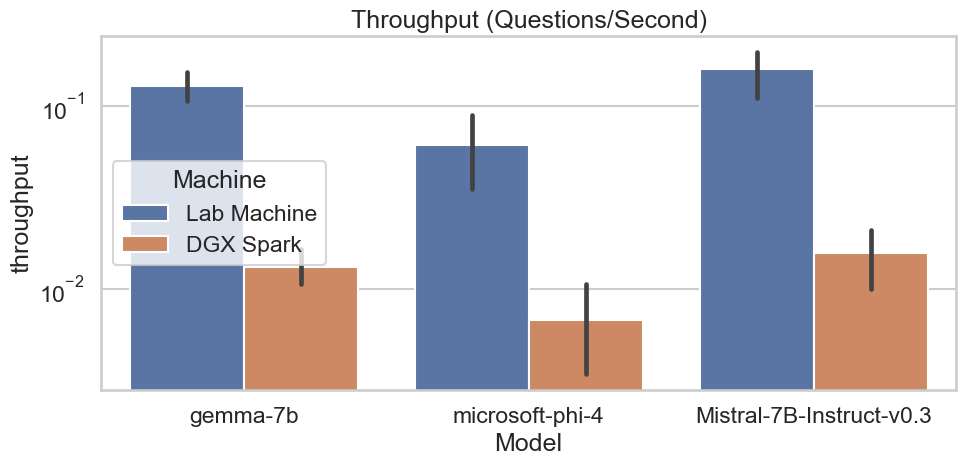

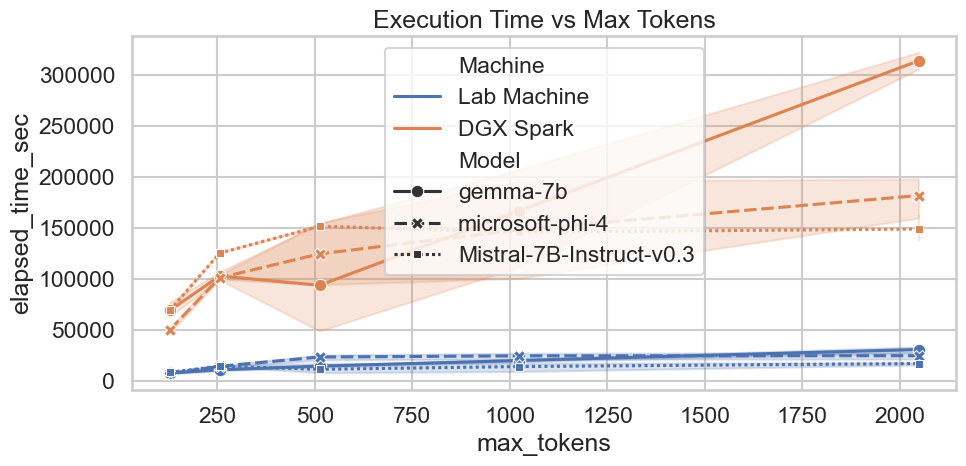

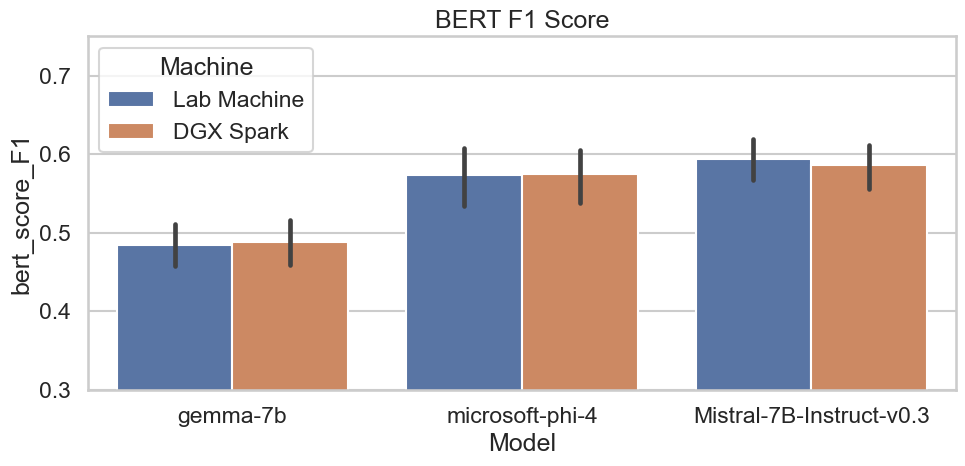

In [11]:
# ============================================================
# 0. Imports
# ============================================================
import pandas as pd
import numpy as np
import re
import os
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt

# ============================================================
# 1. File mappings (combined)
# ============================================================
FILES = {
    'perf': [
        ('gemma-7b', 'Lab Machine', 
         'LMForge_RUN03/qa_run_tracker_detailed_Lab_Machine_gemma-7b.csv',
         'LMForge_RUN03/Generated_Results/gemma-7b/qa_generation_results_Lab_Machine_gemma-7b.csv'),

        ('gemma-7b', 'DGX Spark',
         'LMForge_RUN03_DGX_SPARK_GEMMA/qa_run_tracker_detailed_DGX_Spark_gemma-7b.csv',
         'LMForge_RUN03_DGX_SPARK_GEMMA/Generated_Results/gemma-7b-spark/qa_generation_results_DGX_Spark_gemma-7b.csv'),

        ('microsoft-phi-4', 'Lab Machine',
         'LMForge_RUN04/qa_run_tracker_detailed_Lab_Machine_microsoft_phi-4.csv',
         'LMForge_RUN04/Generated_Results/microsoft_phi-4/qa_generation_results_Lab_Machine_microsoft_phi-4.csv'),

        ('microsoft-phi-4', 'DGX Spark',
         'LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/qa_run_tracker_detailed_DGX_Spark_microsoft_phi-4.csv',
         'LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/Generated_Results/microsoft-Phi-4-mini-instruct-spark/qa_generation_results_DGX_Spark_microsoft_phi-4.csv'),

        ('Mistral-7B-Instruct-v0.3', 'Lab Machine',
         'LMForge_RUN05/qa_run_tracker_detailed_Lab_Machine_Mistral-7B-Instruct-v0.3.csv',
         'LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/qa_generation_results_Lab_Machine_Mistral-7B-Instruct-v0.3.csv'),

        ('Mistral-7B-Instruct-v0.3', 'DGX Spark',
         'LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/qa_run_tracker_detailed_DGX_Spark_Mistral-7B-Instruct-v0.3.csv',
         'LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/Generated_Results/mistralai-Mistral-7B-Instruct-v0.3-spark/qa_generation_results_DGX_Spark_Mistral-7B-Instruct-v0.3.csv'),
    ],

    'scores': [
        ('gemma-7b','Lab Machine',
         'LMForge_RUN03/Generated_Results/gemma-7b/scores_Lab_Machine_gemma-7b.csv'),

        ('gemma-7b','DGX Spark',
         'LMForge_RUN03_DGX_SPARK_GEMMA/Generated_Results/gemma-7b-spark/scores_DGX_Spark_gemma-7b.csv'),

        ('microsoft-phi-4','Lab Machine',
         'LMForge_RUN04/Generated_Results/microsoft_phi-4/scores_Lab_Machine_microsoft_phi-4.csv'),

        ('microsoft-phi-4','DGX Spark',
         'LMForge_RUN04_DGX_SPARK_microsoft-Phi-4-mini-instruct/Generated_Results/microsoft-Phi-4-mini-instruct-spark/scores_DGX_Spark_microsoft_phi-4.csv'),

        ('Mistral-7B-Instruct-v0.3', 'Lab Machine',
         'LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/scores_Lab_Machine_Mistral-7B-Instruct-v0.3.csv'),

        ('Mistral-7B-Instruct-v0.3', 'DGX Spark',
         'LMForge_RUN05_DGX_SPARK_Mistral-7B-Instruct-v0.3/Generated_Results/mistralai-Mistral-7B-Instruct-v0.3-spark/scores_DGX_Spark_Mistral-7B-Instruct-v0.3.csv'),
    ]
}

VALID_CHUNK_SIZES = {128, 256, 512}

# ============================================================
# 2. Robust time parser
# ============================================================
def parse_time_robust(t):
    if not isinstance(t, str):
        return 0
    t = t.strip().replace('"', '')

    try:
        # contains "day"
        if "day" in t:
            d, rest = t.split("day")[0].strip(), t.split(",")[1]
            days = float(d.split()[0])
            h, m, s = rest.strip().split(":")
            total = days*86400 + float(h)*3600 + float(m)*60 + float(s)
            return total
        else:
            h, m, s = t.split(":")
            return float(h)*3600 + float(m)*60 + float(s)
    except:
        return 0

# ============================================================
# 3. Load + Clean Performance Data
# ============================================================
perf_rows = []

for model, machine, tracker_f, results_f in FILES['perf']:
    try:
        df_t = pd.read_csv(tracker_f)
        if 'elapsed_time' in df_t.columns:
            df_t = df_t.drop(columns=['elapsed_time'])

        # Filter valid chunk sizes
        df_t = df_t[df_t['chunk_size'].isin(VALID_CHUNK_SIZES)]

        # Parse results file
        if os.path.exists(results_f):
            df_r = pd.read_csv(results_f)
            df_r['elapsed_time_sec'] = df_r['elapsed_time'].astype(str).apply(parse_time_robust)

            # Filter invalid logs (<30 sec)
            df_r = df_r[df_r['elapsed_time_sec'] > 30]

            # Group by config
            df_time = df_r.groupby(['chunk_size','max_tokens'])['elapsed_time_sec'].max().reset_index()

            df = pd.merge(df_t, df_time, on=['chunk_size','max_tokens'], how='left')

        else:
            df = df_t
            df['elapsed_time_sec'] = np.nan

        df['Model'] = model
        df['Machine'] = machine

        df['total_questions'] = pd.to_numeric(df['total_questions'], errors='coerce').fillna(0)
        df['success_count'] = pd.to_numeric(df['success_count'], errors='coerce').fillna(0)
        df['total_chunks'] = pd.to_numeric(df['total_chunks'], errors='coerce').fillna(0)

        df['success_rate'] = df['success_count'] / df['total_chunks']

        df['throughput'] = df.apply(
            lambda r: r['total_questions']/r['elapsed_time_sec']
            if pd.notna(r['elapsed_time_sec']) and r['elapsed_time_sec']>0 else 0,
            axis=1
        )

        perf_rows.append(df)

    except Exception as e:
        print(f"Error processing {model} {machine}: {e}")

df_perf = pd.concat(perf_rows, ignore_index=True)

# Drop impossible data
df_perf = df_perf[df_perf['elapsed_time_sec'] > 30]

# ============================================================
# 4. Load Score Files
# ============================================================
score_rows = []

for model, machine, score_f in FILES['scores']:
    if os.path.exists(score_f):
        df = pd.read_csv(score_f)
        df = df[df['chunk_size'].isin(VALID_CHUNK_SIZES)]
        df['Model'] = model
        df['Machine'] = machine
        score_rows.append(df)

df_scores = pd.concat(score_rows, ignore_index=True)

# ============================================================
# 5. SAVE MASTER
# ============================================================
os.makedirs("Plots_And_Results", exist_ok=True)
master_csv = "Plots_And_Results/llm_master_clean.csv"
df_perf.to_csv(master_csv, index=False)
print("Saved cleaned master file:", master_csv)

# ============================================================
# 6. PLOTS
# ============================================================
sns.set_theme(style="whitegrid", context="talk")

# ---- Plot: Throughput
plt.figure(figsize=(10,5))
sns.barplot(data=df_perf, x="Model", y="throughput", hue="Machine")
plt.title("Throughput (Questions/Second)")
plt.yscale("log")
plt.tight_layout()
plt.savefig("Plots_And_Results/throughput_clean.png")
plt.show()

# ---- Plot: Time scaling
plt.figure(figsize=(10,5))
sns.lineplot(data=df_perf, x="max_tokens", y="elapsed_time_sec",
             hue="Machine", style="Model", markers=True)
plt.title("Execution Time vs Max Tokens")
plt.tight_layout()
plt.savefig("Plots_And_Results/time_scaling_clean.png")
plt.show()

# ---- Accuracy
plt.figure(figsize=(10,5))
sns.barplot(data=df_scores, x="Model", y="bert_score_F1", hue="Machine")
plt.title("BERT F1 Score")
plt.ylim(0.3, 0.75)
plt.tight_layout()
plt.savefig("Plots_And_Results/accuracy_clean.png")
plt.show()

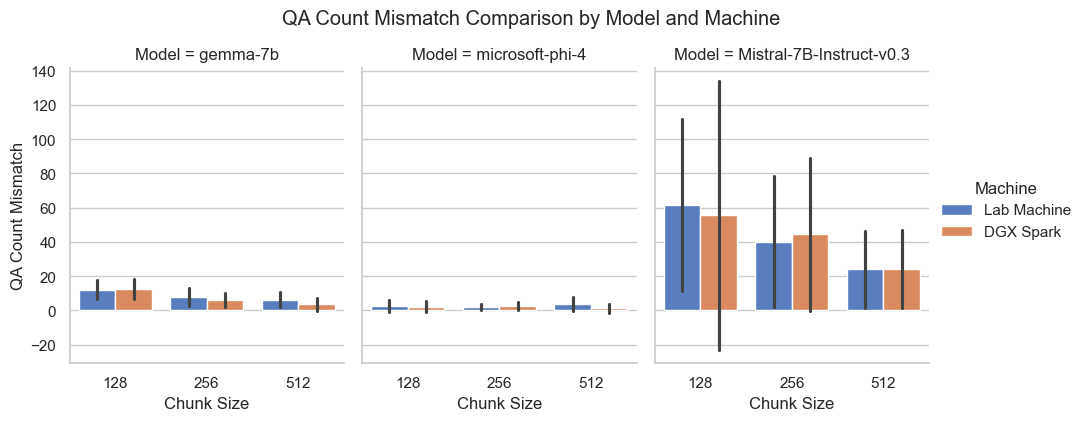

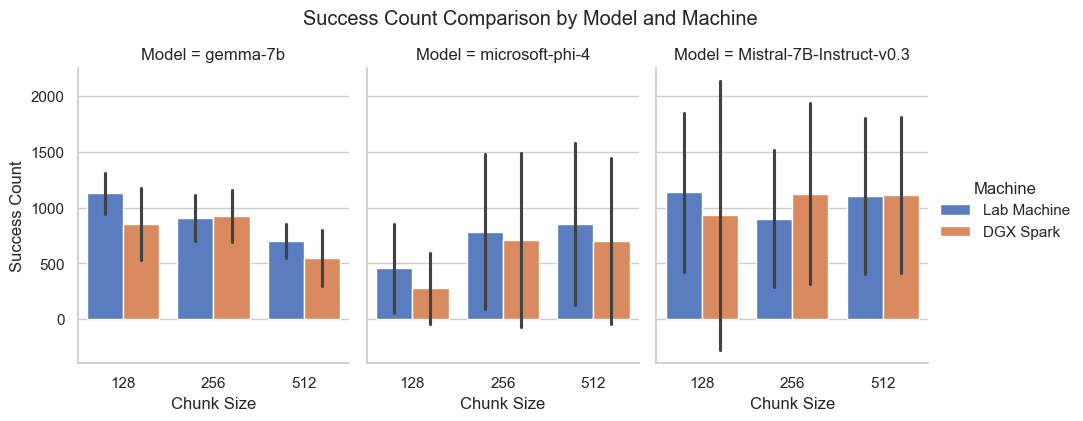

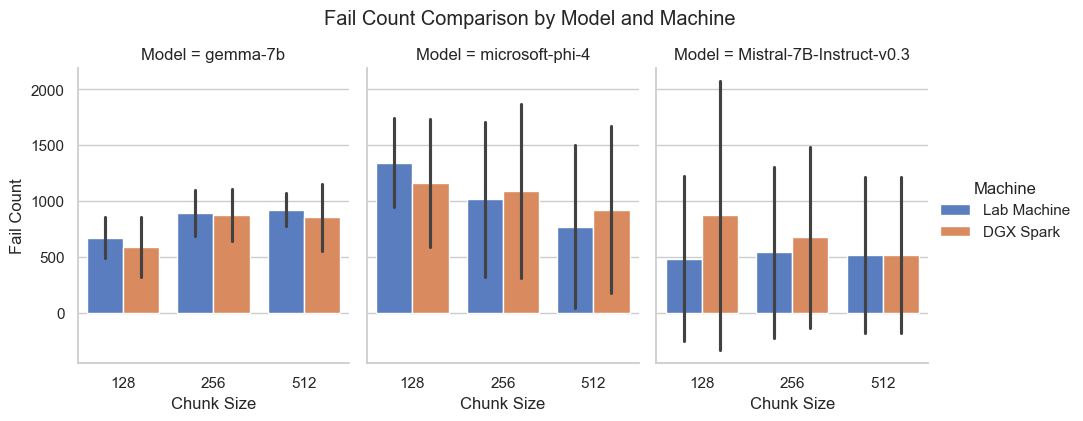

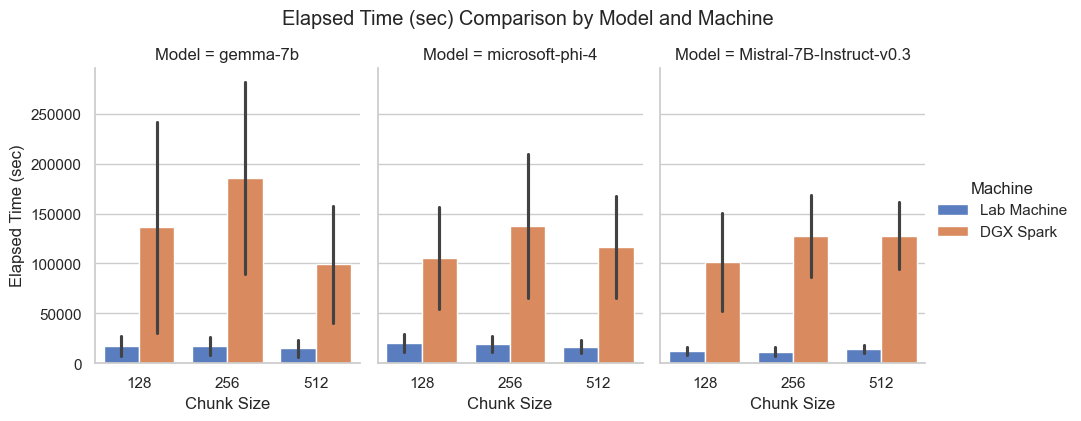

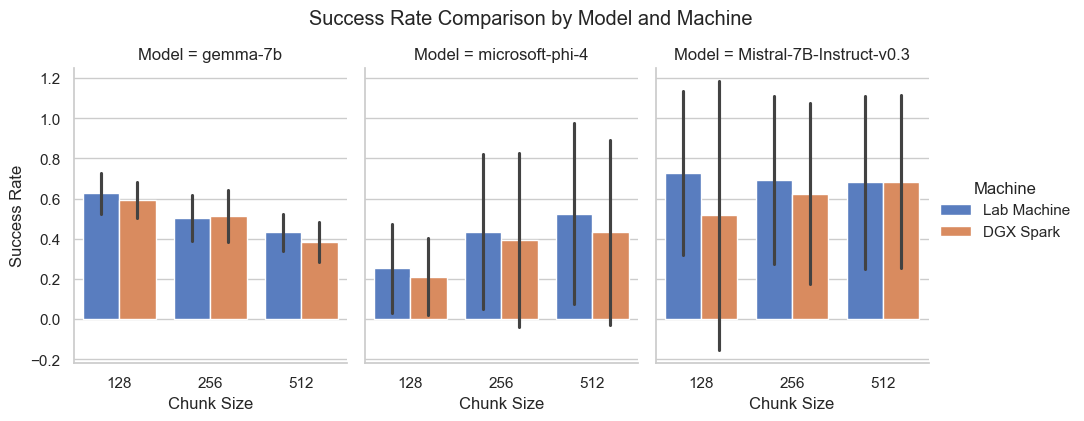

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
# Ensure the CSV file is in the same directory or provide the full path
df = pd.read_csv('Plots_And_Results/llm_master_clean.csv')

# 1. Filter the data
# Keep only chunk sizes 128, 256, and 512 (Ignoring 1024)
filtered_df = df[df['chunk_size'].isin([128, 256, 512])]

# Set the visualization style
sns.set(style="whitegrid")

# List of variables to plot
# Each tuple contains the column name and a display title
metrics = [
    ('qa_count_mismatch', 'QA Count Mismatch'),
    ('success_count', 'Success Count'),
    ('fail_count', 'Fail Count'),
    ('elapsed_time_sec', 'Elapsed Time (sec)'),
    ('success_rate', 'Success Rate')
]

# Generate a plot for each metric
for col_name, title in metrics:
    # Create a faceted bar chart
    # x-axis: chunk_size
    # y-axis: the metric
    # hue: Machine (Lab Machine vs DGX Spark)
    # col: Model (Separate chart for each model)
    g = sns.catplot(
        data=filtered_df,
        x='chunk_size',
        y=col_name,
        hue='Machine',
        col='Model',
        kind='bar',
        height=4,
        aspect=0.8,
        palette='muted',
        errorbar='sd',  # Shows standard deviation if there are multiple entries per chunk
        legend_out=True
    )
    
    # Add titles and adjust layout
    g.fig.suptitle(f'{title} Comparison by Model and Machine', y=1.05)
    g.set_axis_labels("Chunk Size", title)
    
    plt.show()

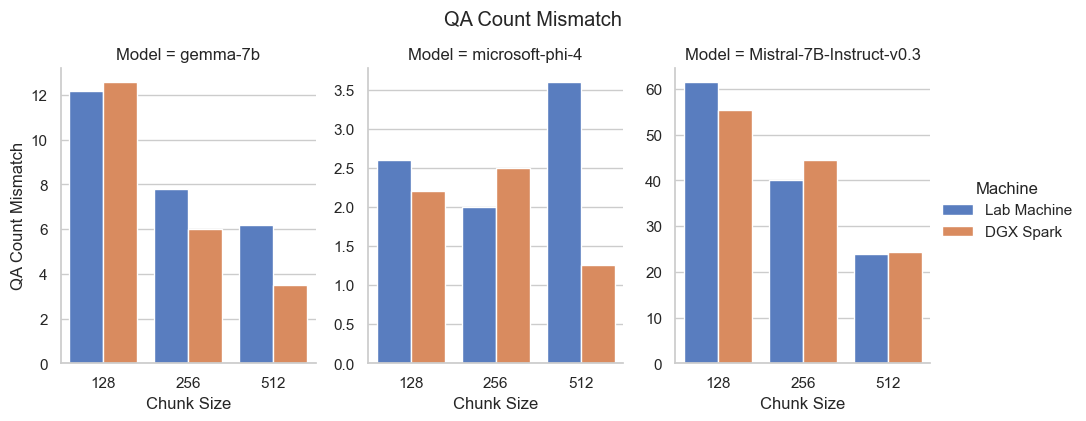

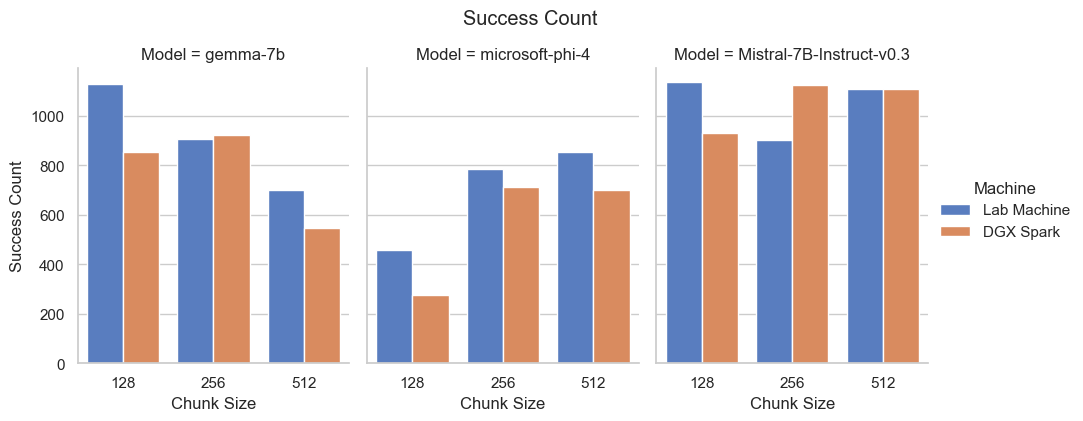

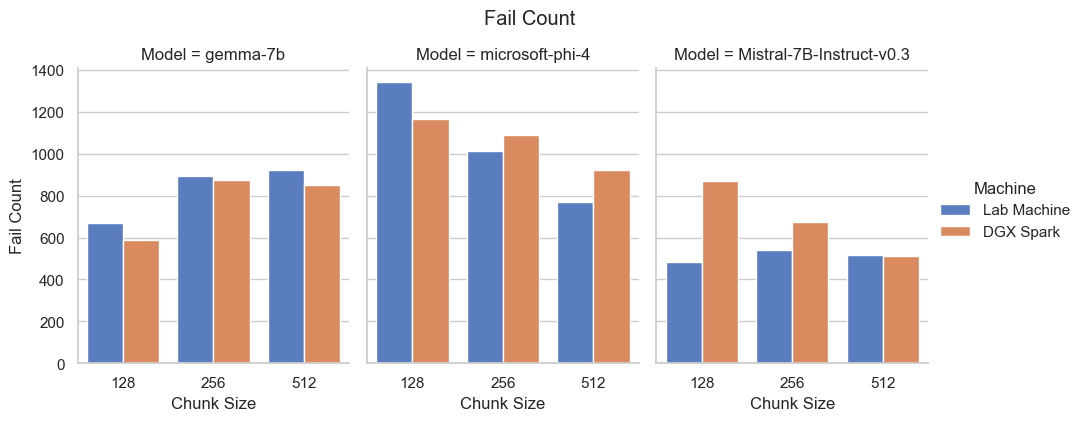

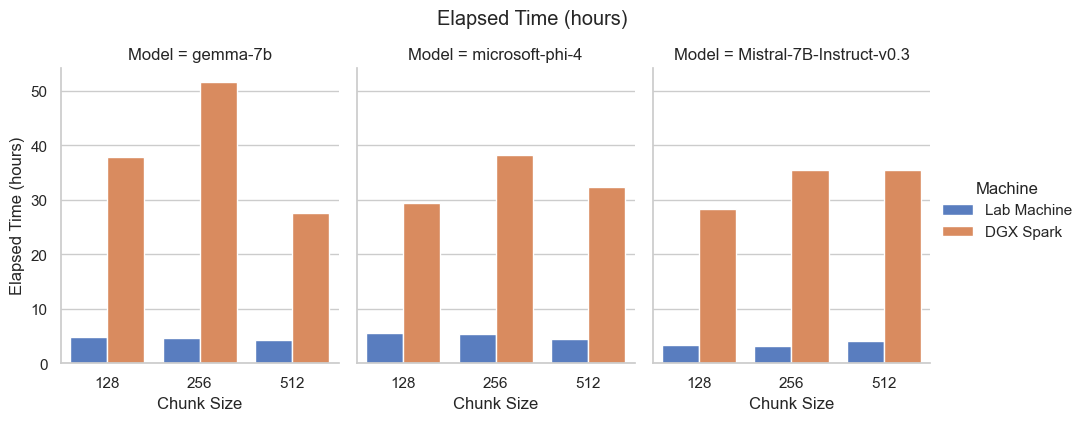

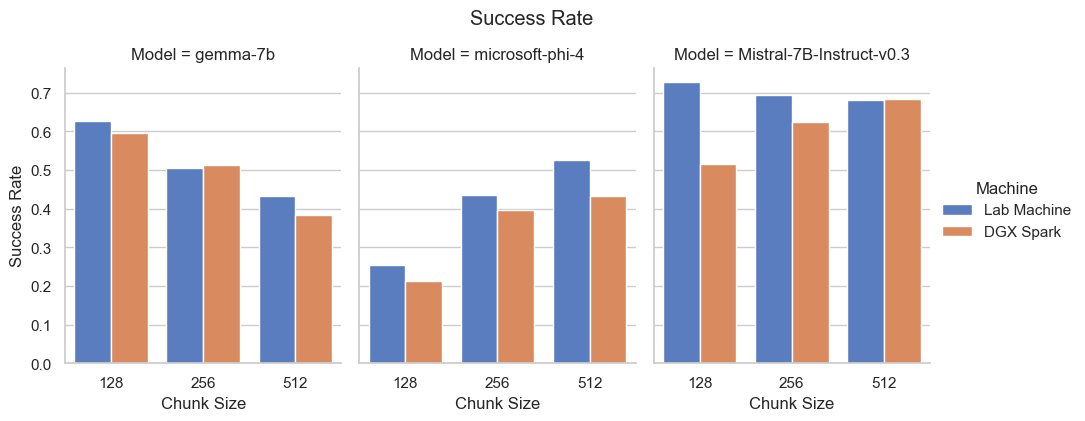

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Plots_And_Results/llm_master_clean.csv')

# Filter for specific chunk sizes
filtered_df = df[df['chunk_size'].isin([128, 256, 512])].copy()

# 1. Convert elapsed time from seconds to hours
filtered_df['elapsed_time_hours'] = filtered_df['elapsed_time_sec'] / 3600

# Set visualization style
sns.set(style="whitegrid")

# 2. Plot QA Count Mismatch with independent scales
# sharey=False allows each model's plot to have its own y-axis range
g_qa = sns.catplot(
    data=filtered_df,
    x='chunk_size',
    y='qa_count_mismatch',
    hue='Machine',
    col='Model',
    kind='bar',
    height=4,
    aspect=0.8,
    palette='muted',
    errorbar=None,
    sharey=False  # KEY CHANGE: Independent scales for each subplot
)
g_qa.fig.suptitle('QA Count Mismatch', y=1.05)
g_qa.set_axis_labels("Chunk Size", "QA Count Mismatch")
plt.show()

# Plot the rest of the metrics (Success, Fail, Time in Hours, Rate)
metrics = [
    ('success_count', 'Success Count'),
    ('fail_count', 'Fail Count'),
    ('elapsed_time_hours', 'Elapsed Time (hours)'), # Updated metric
    ('success_rate', 'Success Rate')
]

for col_name, title in metrics:
    g = sns.catplot(
        data=filtered_df,
        x='chunk_size',
        y=col_name,
        hue='Machine',
        col='Model',
        kind='bar',
        height=4,
        aspect=0.8,
        palette='muted',
        errorbar=None   # KEY CHANGE: Removes the error bars
    )
    g.fig.suptitle(f'{title}', y=1.05)
    g.set_axis_labels("Chunk Size", title)
    plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Data for Plots (re-using logic from previous turn)
def parse_timedelta_string(ts):
    if pd.isna(ts): return 0
    if 'days' in str(ts): return pd.to_timedelta(ts).total_seconds() / 60.0
    try: return pd.to_timedelta(ts).total_seconds() / 60.0
    except: return 0

# Load Gemma
df_gemma = pd.read_csv("qa_generation_results_Lab_Machine_gemma-7b.csv")
df_gemma = df_gemma.drop_duplicates(subset=['chunk_size', 'max_tokens'])
df_gemma = df_gemma[['chunk_size', 'max_tokens', 'success_count', 'fail_count', 'total_chunks', 'elapsed_time']]
df_gemma['elapsed_time_min'] = df_gemma['elapsed_time'].apply(parse_timedelta_string)
df_gemma['model'] = 'Gemma-7B'
df_gemma['bert_score_F1'] = np.nan
df_gemma['rougeL'] = np.nan

# Load Others
models_info = [
    {'name': 'Phi-4', 'tracker': "qa_run_tracker_detailed_Lab_Machine_microsoft_phi-4.csv", 'scores': "scores_Lab_Machine_microsoft_phi-4.csv"},
    {'name': 'Mistral-7B', 'tracker': "qa_run_tracker_detailed_Lab_Machine_Mistral-7B-Instruct-v0.3.csv", 'scores': "scores_Lab_Machine_Mistral-7B-Instruct-v0.3.csv"},
    {'name': 'Qwen-2.5-7B', 'tracker': "qa_run_tracker_detailed_Lab_Machine_Qwen2.5-7B-Instruct.csv", 'scores': "scores_Qwen2.5-7B-Instruct.csv"}
]

df_list = [df_gemma]
for m in models_info:
    df_tracker = pd.read_csv(m['tracker'])
    df_scores = pd.read_csv(m['scores'])
    # Ensure types match for merge
    df_tracker['chunk_size'] = df_tracker['chunk_size'].astype(int)
    df_tracker['max_tokens'] = df_tracker['max_tokens'].astype(int)
    df_scores['chunk_size'] = df_scores['chunk_size'].astype(int)
    df_scores['max_tokens'] = df_scores['max_tokens'].astype(int)
    
    # Aggregating scores to get one row per configuration (mean score)
    # The previous code merged raw lines, but for plotting "by configuration" we need aggregates if rows are duplicated or multiple runs
    # However, the user's data seems to have one row per config in tracker, but multiple in scores?
    # Let's group scores by chunk_size, max_tokens first to match tracker granularity
    scores_agg = df_scores.groupby(['chunk_size', 'max_tokens'])[['elapsed_time', 'bert_score_F1', 'rougeL']].agg({
        'elapsed_time': 'first', # Usually one time per batch
        'bert_score_F1': 'mean',
        'rougeL': 'mean'
    }).reset_index()
    
    # Merge
    df_merged = pd.merge(df_tracker[['chunk_size', 'max_tokens', 'success_count', 'fail_count', 'total_chunks']],
                         scores_agg,
                         on=['chunk_size', 'max_tokens'],
                         how='inner')
    
    df_merged['elapsed_time_min'] = df_merged['elapsed_time'].apply(parse_timedelta_string)
    df_merged['model'] = m['name']
    df_list.append(df_merged)

full_df = pd.concat(df_list, ignore_index=True)
full_df['success_rate'] = full_df['success_count'] / full_df['total_chunks']
full_df['max_tokens'] = full_df['max_tokens'].astype(str) # For categorical plotting

# 2. Generate Bar Charts
sns.set_theme(style="whitegrid")

# Helper to save
def save_barplot(data, x, y, hue, title, filename, ylabel):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=data, x=x, y=y, hue=hue, palette="viridis")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Max Tokens")
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"{filename}.png")
    print(f"Saved {filename}.png")

# Plot 1: Elapsed Time (Bar)
save_barplot(full_df, "max_tokens", "elapsed_time_min", "model", 
             "Elapsed Time by Model and Token Limit", "bar_elapsed_time", "Time (Minutes)")

# Plot 2: Success Rate (Bar)
save_barplot(full_df, "max_tokens", "success_rate", "model", 
             "Success Rate by Model and Token Limit", "bar_success_rate", "Success Rate")

# Plot 3: BERT F1 (Bar) - excluding Gemma
save_barplot(full_df[full_df['model']!='Gemma-7B'], "max_tokens", "bert_score_F1", "model", 
             "BERT F1 Score by Model and Token Limit", "bar_bert_f1", "BERT F1 Score")

# 3. Analyze Statistical Files
stat_files = [
    "pairwise_ttests_fdr_GEMMA_7B.csv",
    "pairwise_ttests_fdr_microsoft_phi-4.csv",
    "pairwise_ttests_fdr_Mistral-7B-Instruct-v0.3.csv",
    "pairwise_ttests_fdr_Qwen2.5-7B-Instruct.csv"
]

stat_summaries = {}

for f in stat_files:
    model_name = f.replace("pairwise_ttests_fdr_", "").replace(".csv", "")
    try:
        df_stat = pd.read_csv(f)
        # Filter for significant results
        sig_results = df_stat[df_stat['Significant (FDR < 0.05)'] == True]
        stat_summaries[model_name] = sig_results
        print(f"\n--- {model_name} Significant Results ---")
        print(sig_results[['Outcome', 'Group 1', 'Group 2', 't-statistic']].head())
    except Exception as e:
        print(f"Error reading {f}: {e}")


SUCCESS RATE CALCULATION BREAKDOWN
| model       |   chunk_size |   max_tokens |   success_count |   total_chunks |   success_rate |
|:------------|-------------:|-------------:|----------------:|---------------:|---------------:|
| Gemma-7B    |          128 |          128 |             811 |           1800 |     0.450556   |
| Gemma-7B    |          128 |          256 |            1127 |           1800 |     0.626111   |
| Gemma-7B    |          128 |          512 |            1233 |           1800 |     0.685      |
| Gemma-7B    |          128 |         1024 |            1237 |           1800 |     0.687222   |
| Gemma-7B    |          128 |         2048 |            1237 |           1800 |     0.687222   |
| Gemma-7B    |          256 |          128 |             569 |           1800 |     0.316111   |
| Gemma-7B    |          256 |          256 |             864 |           1800 |     0.48       |
| Gemma-7B    |          256 |          512 |            1021 |           1800 |  

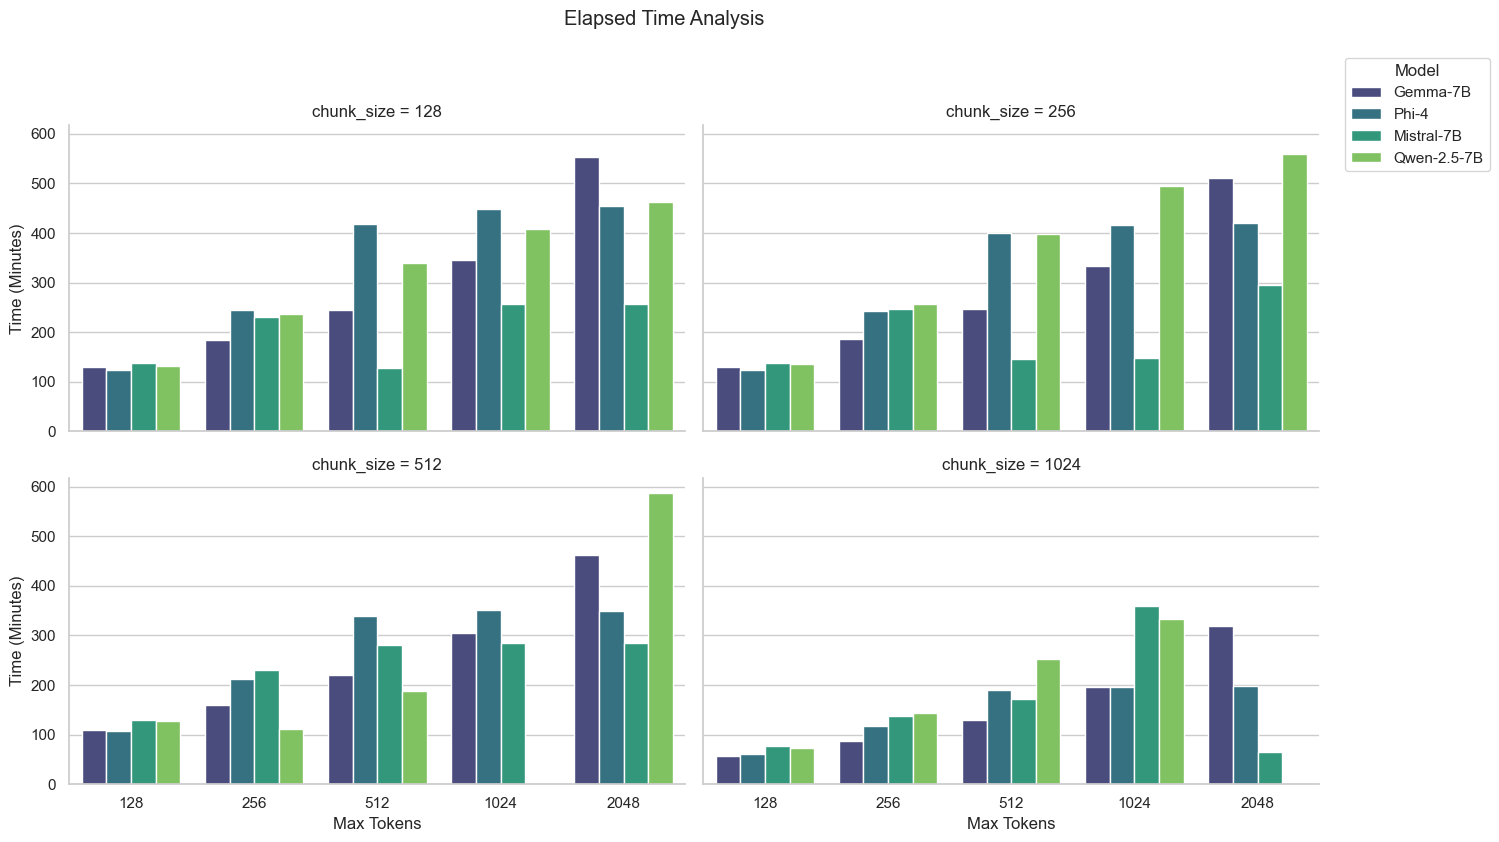

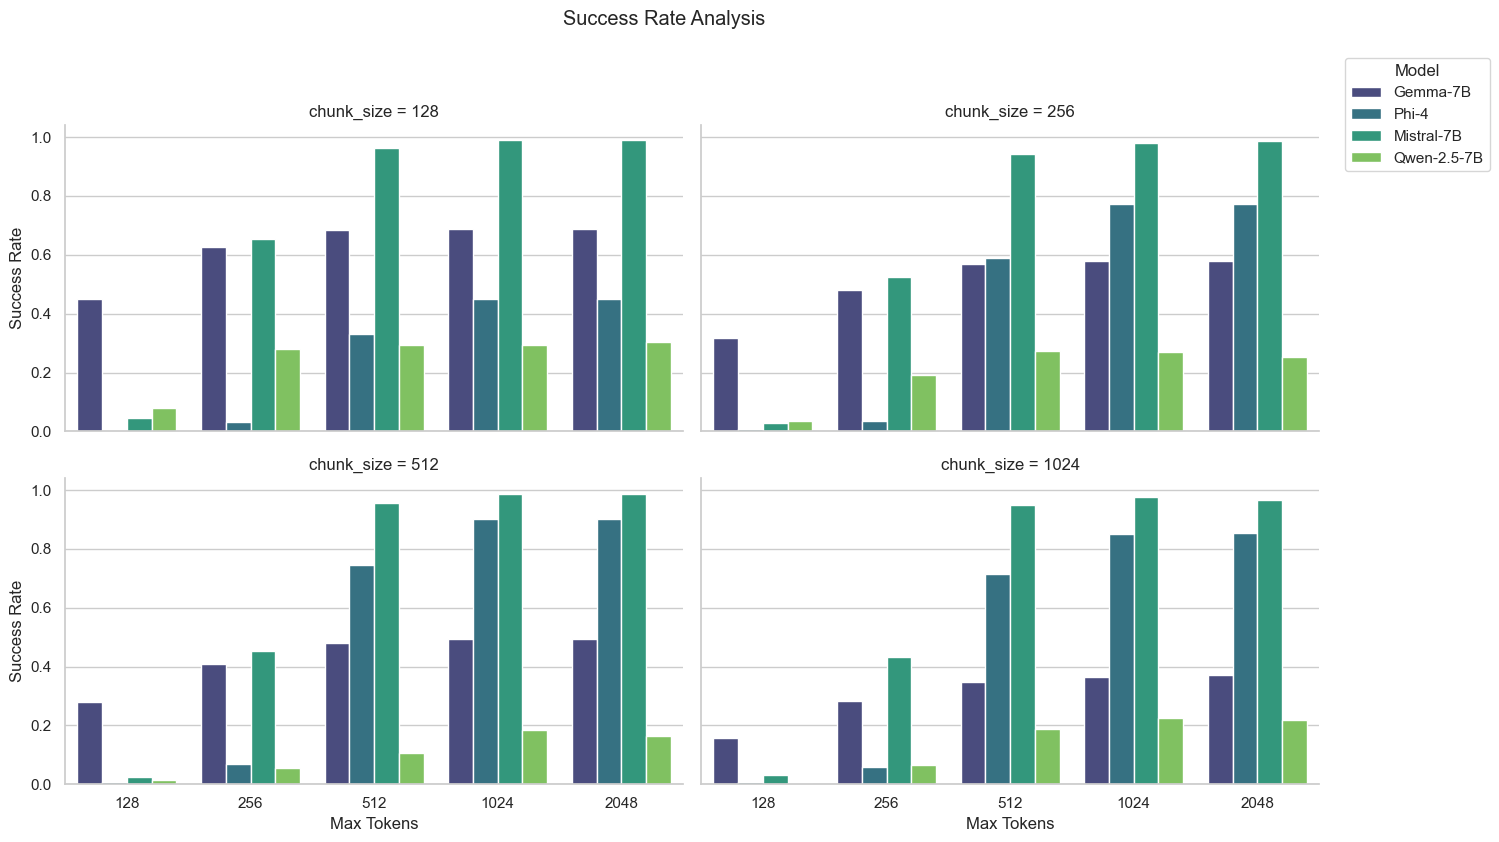

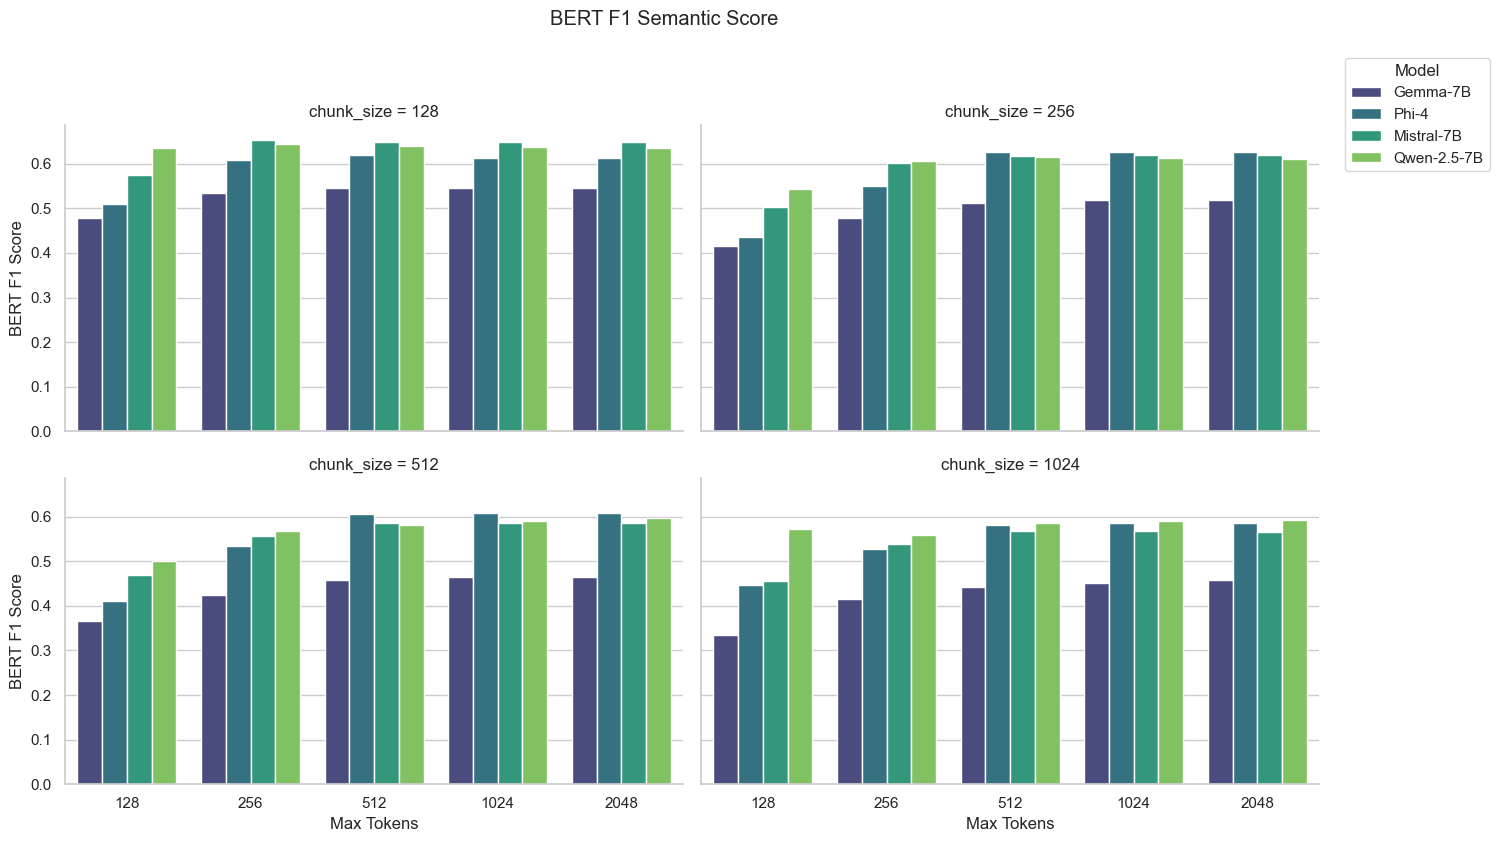

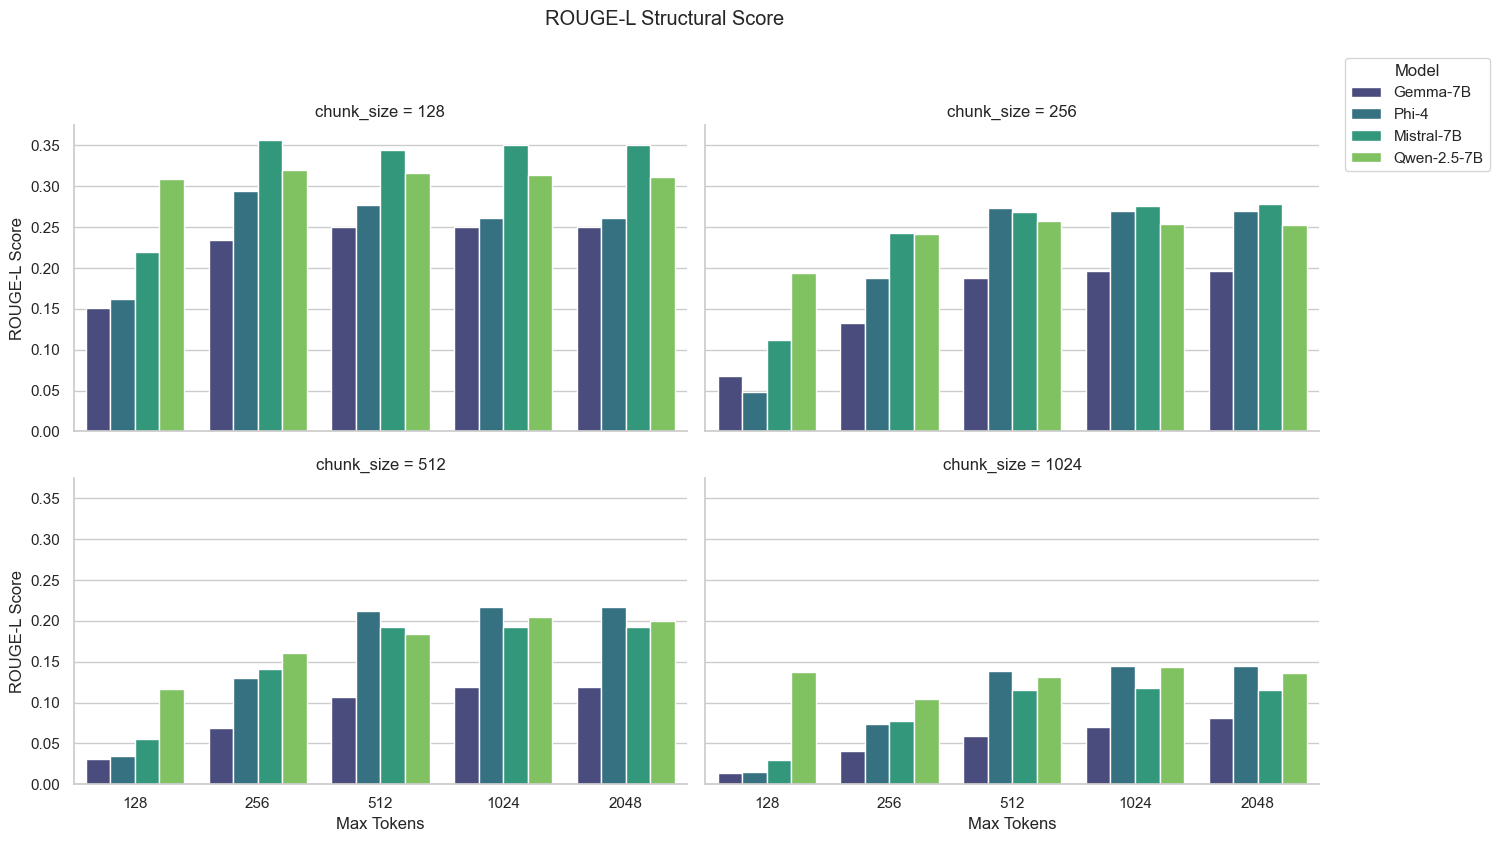

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Helper function for time parsing
def parse_timedelta_string(ts):
    if pd.isna(ts): return 0
    ts_str = str(ts)
    if 'days' in ts_str: 
        return pd.to_timedelta(ts).total_seconds() / 60.0
    try: 
        return pd.to_timedelta(ts).total_seconds() / 60.0
    except: 
        return 0

# 2. Define all models with their respective Tracker and Score files
models_info = [
    {
        'name': 'Gemma-7B', 
        'tracker': "LMForge_RUN03/qa_run_tracker_detailed_Lab_Machine_gemma-7b.csv", 
        'scores': "LMForge_RUN03/Generated_Results/gemma-7b/scores_Lab_Machine_gemma-7b.csv"
    },
    {
        'name': 'Phi-4', 
        'tracker': "LMForge_RUN04/qa_run_tracker_detailed_Lab_Machine_microsoft_phi-4.csv", 
        'scores': "LMForge_RUN04/Generated_Results/microsoft_phi-4/scores_Lab_Machine_microsoft_phi-4.csv"
    },
    {
        'name': 'Mistral-7B', 
        'tracker': "LMForge_RUN05/qa_run_tracker_detailed_Lab_Machine_Mistral-7B-Instruct-v0.3.csv", 
        'scores': "LMForge_RUN05/Generated_Results/Mistral-7B-Instruct-v0.3/scores_Lab_Machine_Mistral-7B-Instruct-v0.3.csv"
    },
    {
        'name': 'Qwen-2.5-7B', 
        'tracker': "LMForge_RUN06/qa_run_tracker_detailed_Lab_Machine_Qwen2.5-7B-Instruct.csv", 
        'scores': "LMForge_RUN06/Generated_Results/Qwen2.5-7B-Instruct/scores_Qwen2.5-7B-Instruct.csv"
    }
]

df_list = []

for m in models_info:
    try:
        # Load Tracker and Scores
        df_tracker = pd.read_csv(m['tracker'])
        df_scores = pd.read_csv(m['scores'])
        
        # Ensure join keys are integers for correct merging
        for df in [df_tracker, df_scores]:
            df['chunk_size'] = df['chunk_size'].astype(int)
            df['max_tokens'] = df['max_tokens'].astype(int)
        
        # Aggregate scores by configuration (taking the mean)
        scores_agg = df_scores.groupby(['chunk_size', 'max_tokens'])[['elapsed_time', 'bert_score_F1', 'rougeL']].agg({
            'elapsed_time': 'first',
            'bert_score_F1': 'mean',
            'rougeL': 'mean'
        }).reset_index()
        
        # Merge Tracker (Success/Fail) with Scores (Quality)
        df_merged = pd.merge(
            df_tracker[['chunk_size', 'max_tokens', 'success_count', 'fail_count', 'total_chunks']],
            scores_agg,
            on=['chunk_size', 'max_tokens'],
            how='inner'
        )
        
        # Process metrics
        df_merged['elapsed_time_min'] = df_merged['elapsed_time'].apply(parse_timedelta_string)
        df_merged['model'] = m['name']
        df_list.append(df_merged)
        
    except Exception as e:
        print(f"Error processing {m['name']}: {e}")

# Combine all data
full_df = pd.concat(df_list, ignore_index=True)
full_df['success_rate'] = full_df['success_count'] / full_df['total_chunks']
full_df['max_tokens'] = full_df['max_tokens'].astype(str) # For categorical plotting

# --- NEW: Print Calculation Details ---
print("\n" + "="*50)
print("SUCCESS RATE CALCULATION BREAKDOWN")
print("="*50)
print(full_df[['model', 'chunk_size', 'max_tokens', 'success_count', 'total_chunks', 'success_rate']].to_markdown(index=False))
print("\n")


# --- Plotting ---
sns.set_theme(style="whitegrid")

def save_faceted_barplot(data, x, y, hue, col, title, filename, ylabel):
    g = sns.catplot(
        data=data, 
        kind="bar",
        x=x, 
        y=y, 
        hue=hue, 
        col=col,       
        col_wrap=2,    
        palette="viridis",
        height=4, 
        aspect=1.5
    )
    
    # Increase title height slightly to make room for legend if needed
    g.fig.suptitle(title, y=1.05)
    g.set_axis_labels("Max Tokens", ylabel)
    
    # --- MOVED LEGEND TO TOP LEFT ---
    # loc='upper left' anchors the top-left corner of the legend box...
    # bbox_to_anchor=(0, 1) ...to the top-left corner of the figure container.
    sns.move_legend(
        g, "upper left", 
        bbox_to_anchor=(1, 1), 
        title="Model",
        frameon=True  # Optional: adds a box around the legend
    )
    
    plt.tight_layout()
    plt.savefig(f"{filename}.png")

# Generate Plots
save_faceted_barplot(full_df, "max_tokens", "elapsed_time_min", "model", "chunk_size",
                     "Elapsed Time Analysis", "faceted_elapsed_time", "Time (Minutes)")

save_faceted_barplot(full_df, "max_tokens", "success_rate", "model", "chunk_size",
                     "Success Rate Analysis", "faceted_success_rate", "Success Rate")

save_faceted_barplot(full_df, "max_tokens", "bert_score_F1", "model", "chunk_size",
                     "BERT F1 Semantic Score", "faceted_bert_f1", "BERT F1 Score")

save_faceted_barplot(full_df, "max_tokens", "rougeL", "model", "chunk_size",
                     "ROUGE-L Structural Score", "faceted_rouge_l", "ROUGE-L Score")

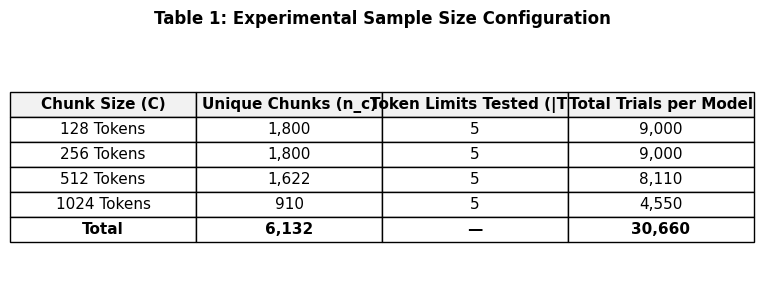

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Data for the table
data = {
    "Chunk Size (C)": ["128 Tokens", "256 Tokens", "512 Tokens", "1024 Tokens", "Total"],
    "Unique Chunks (n_c)": ["1,800", "1,800", "1,622", "910", "6,132"],
    "Token Limits Tested (|T|)": ["5", "5", "5", "5", "—"],
    "Total Trials per Model": ["9,000", "9,000", "8,110", "4,550", "30,660"]
}

# Create DataFrame
df = pd.DataFrame(data)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 3)) # Adjust size as needed
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Styling the table
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5) # Adjust scale for better readability

# Bold the headers
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f2f2f2') # Light gray background for headers
    if row == 5: # Total row
        cell.set_text_props(weight='bold')

plt.title("Table 1: Experimental Sample Size Configuration", pad=20, weight='bold')
plt.show()


SUCCESS RATE CALCULATION BREAKDOWN
| model       |   chunk_size |   max_tokens |   success_count |   total_chunks |   success_rate |
|:------------|-------------:|-------------:|----------------:|---------------:|---------------:|
| Lab_Machine |          128 |          128 |              37 |            200 |          0.185 |
| Lab_Machine |          128 |          256 |              84 |            200 |          0.42  |
| Lab_Machine |          128 |          512 |              85 |            200 |          0.425 |
| Lab_Machine |          128 |         1024 |              79 |            200 |          0.395 |
| Lab_Machine |          128 |         2048 |              90 |            200 |          0.45  |
| Lab_Machine |          256 |          128 |              27 |            200 |          0.135 |
| Lab_Machine |          256 |          256 |              98 |            200 |          0.49  |
| Lab_Machine |          256 |          512 |             111 |            200 |  

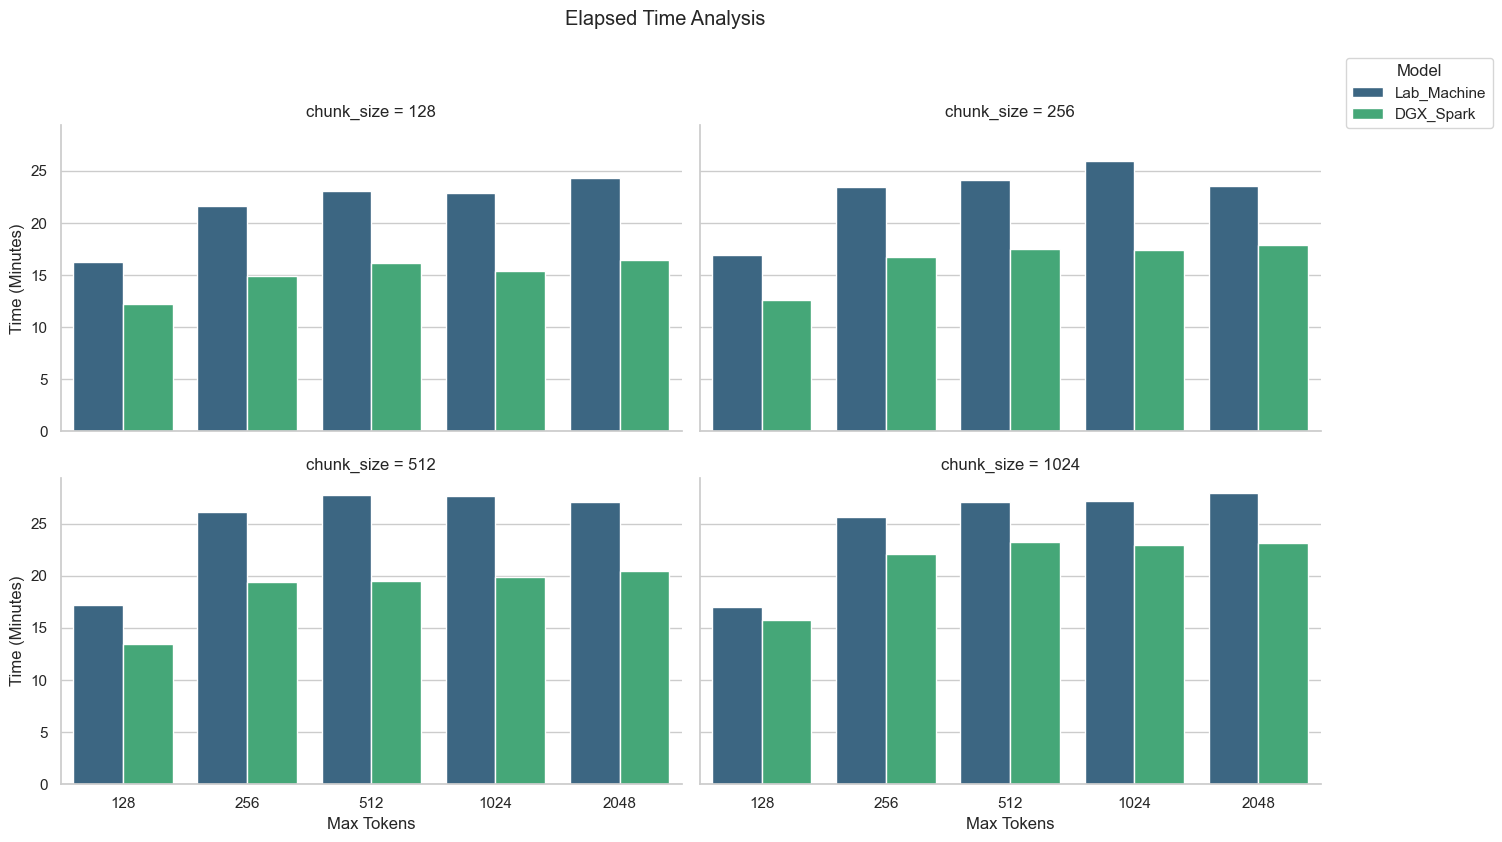

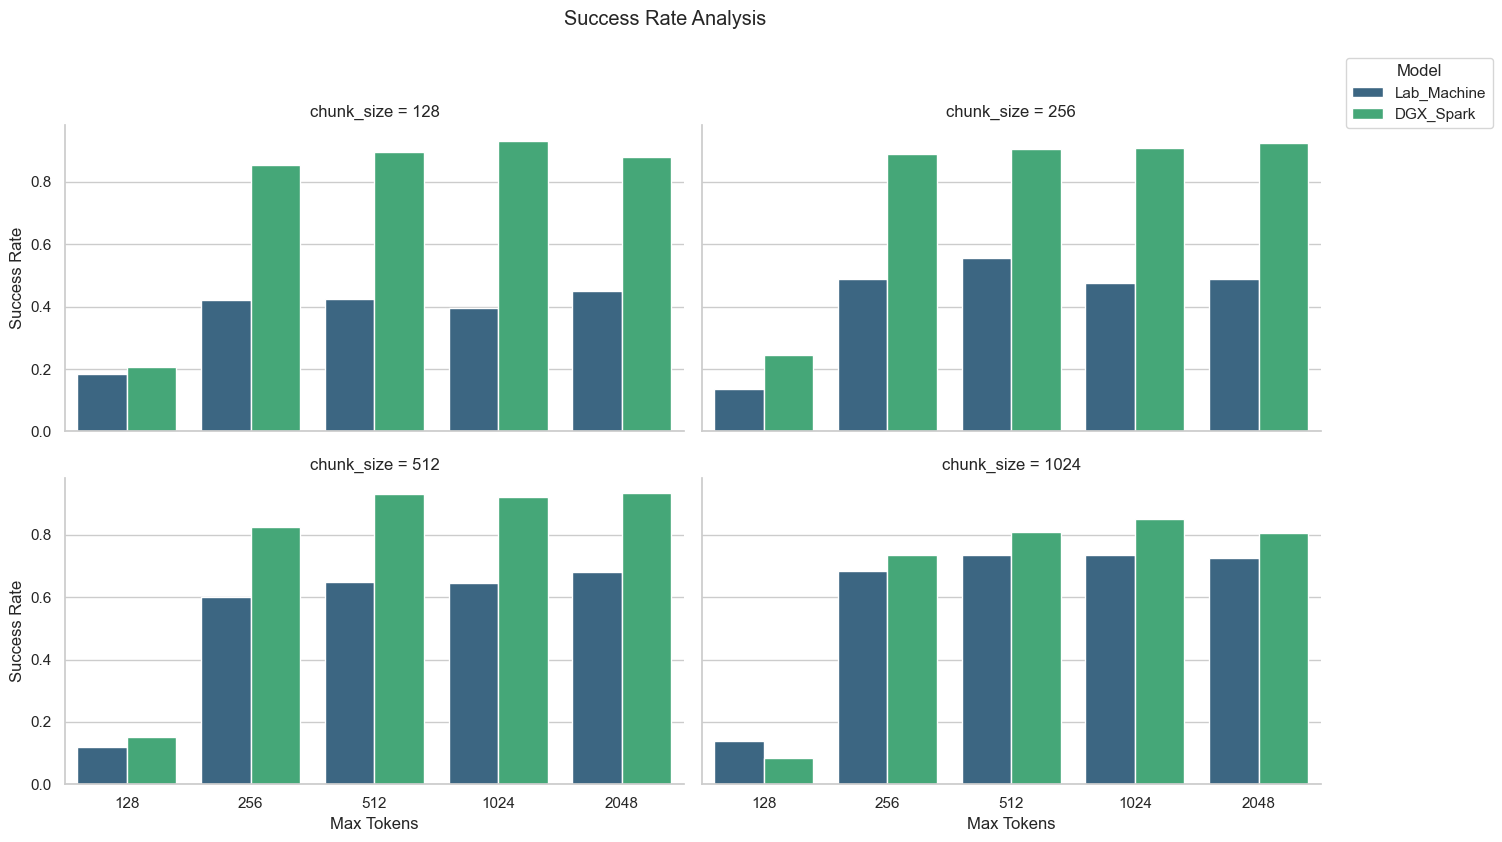

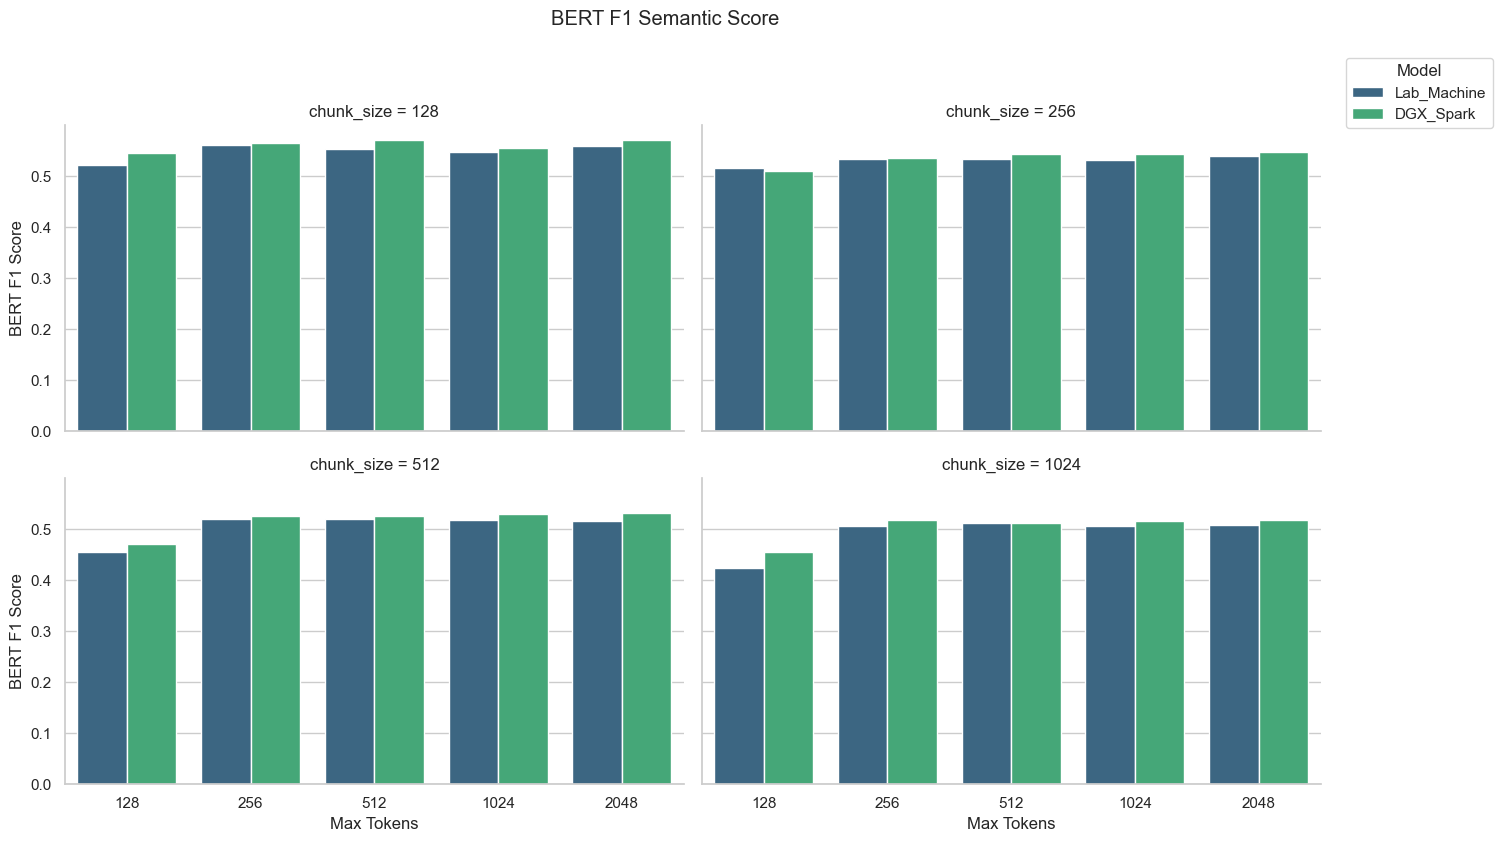

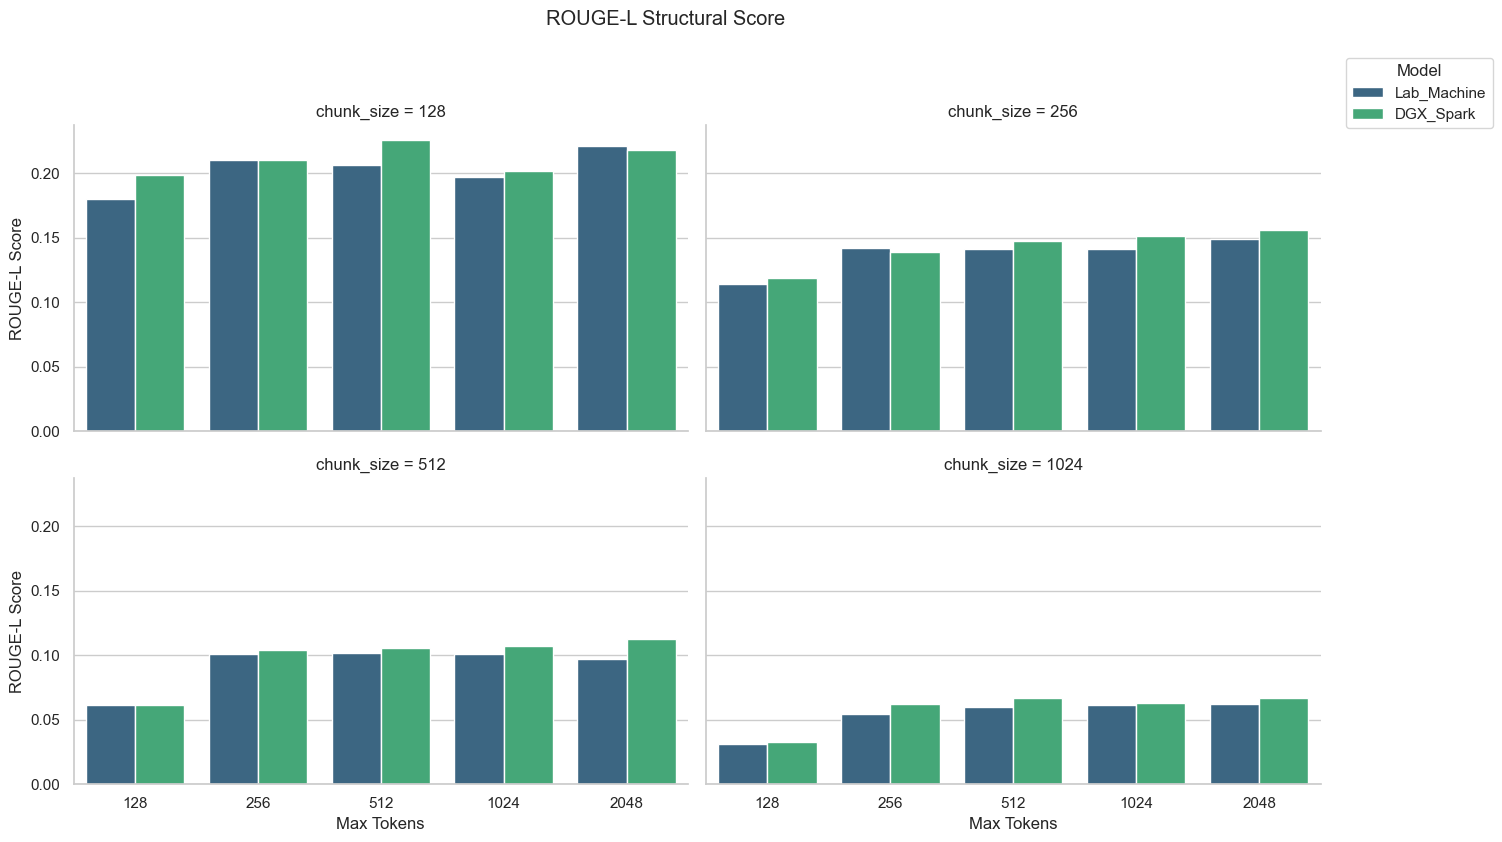

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Helper function for time parsing
def parse_timedelta_string(ts):
    if pd.isna(ts): return 0
    ts_str = str(ts)
    if 'days' in ts_str: 
        return pd.to_timedelta(ts).total_seconds() / 60.0
    try: 
        return pd.to_timedelta(ts).total_seconds() / 60.0
    except: 
        return 0

# 2. Define all models with their respective Tracker and Score files
models_info = [
    {
        'name': 'Lab_Machine', 
        'tracker': "LMForge_RUN01_Devices_Comparison_Lab_Machine_Qwen2.5-1.5B-Instruct/Lab_Machine_Qwen2.5-1.5B-Instruct_qa_run_tracker_detailed.csv", 
        'scores': "LMForge_RUN01_Devices_Comparison_Lab_Machine_Qwen2.5-1.5B-Instruct/Generated_Results/Qwen2.5-1.5B-Instruct/Lab_Machine_Qwen2.5-1.5B-Instruct_scores.csv"
    },
    {
        'name': 'DGX_Spark', 
        'tracker': "LMForge_RUN01_Devices_Comparison_DGX_Spark_Qwen2.5-1.5B-Instruct/DGX_Spark_Qwen2.5-1.5B-Instruct_qa_run_tracker_detailed.csv", 
        'scores': "LMForge_RUN01_Devices_Comparison_DGX_Spark_Qwen2.5-1.5B-Instruct/Generated_Results/Qwen2.5-1.5B-Instruct_DGX_Spark/DGX_Spark_Qwen2.5-1.5B-Instruct_scores.csv"
    },
]

df_list = []

for m in models_info:
    try:
        # Load Tracker and Scores
        df_tracker = pd.read_csv(m['tracker'])
        df_scores = pd.read_csv(m['scores'])
        
        # Ensure join keys are integers for correct merging
        for df in [df_tracker, df_scores]:
            df['chunk_size'] = df['chunk_size'].astype(int)
            df['max_tokens'] = df['max_tokens'].astype(int)
        
        # Aggregate scores by configuration (taking the mean)
        scores_agg = df_scores.groupby(['chunk_size', 'max_tokens'])[['elapsed_time', 'bert_score_F1', 'rougeL']].agg({
            'elapsed_time': 'first',
            'bert_score_F1': 'mean',
            'rougeL': 'mean'
        }).reset_index()
        
        # Merge Tracker (Success/Fail) with Scores (Quality)
        df_merged = pd.merge(
            df_tracker[['chunk_size', 'max_tokens', 'success_count', 'fail_count', 'total_chunks']],
            scores_agg,
            on=['chunk_size', 'max_tokens'],
            how='inner'
        )
        
        # Process metrics
        df_merged['elapsed_time_min'] = df_merged['elapsed_time'].apply(parse_timedelta_string)
        df_merged['model'] = m['name']
        df_list.append(df_merged)
        
    except Exception as e:
        print(f"Error processing {m['name']}: {e}")

# Combine all data
full_df = pd.concat(df_list, ignore_index=True)
full_df['success_rate'] = full_df['success_count'] / full_df['total_chunks']
full_df['max_tokens'] = full_df['max_tokens'].astype(str) # For categorical plotting

# --- NEW: Print Calculation Details ---
print("\n" + "="*50)
print("SUCCESS RATE CALCULATION BREAKDOWN")
print("="*50)
print(full_df[['model', 'chunk_size', 'max_tokens', 'success_count', 'total_chunks', 'success_rate']].to_markdown(index=False))
print("\n")


# --- Plotting ---
sns.set_theme(style="whitegrid")

def save_faceted_barplot(data, x, y, hue, col, title, filename, ylabel):
    g = sns.catplot(
        data=data, 
        kind="bar",
        x=x, 
        y=y, 
        hue=hue, 
        col=col,       
        col_wrap=2,    
        palette="viridis",
        height=4, 
        aspect=1.5
    )
    
    # Increase title height slightly to make room for legend if needed
    g.fig.suptitle(title, y=1.05)
    g.set_axis_labels("Max Tokens", ylabel)
    
    # --- MOVED LEGEND TO TOP LEFT ---
    # loc='upper left' anchors the top-left corner of the legend box...
    # bbox_to_anchor=(0, 1) ...to the top-left corner of the figure container.
    sns.move_legend(
        g, "upper left", 
        bbox_to_anchor=(1, 1), 
        title="Model",
        frameon=True  # Optional: adds a box around the legend
    )
    
    plt.tight_layout()
    plt.savefig(f"{filename}.png")

# Generate Plots
save_faceted_barplot(full_df, "max_tokens", "elapsed_time_min", "model", "chunk_size",
                     "Elapsed Time Analysis", "faceted_elapsed_time", "Time (Minutes)")

save_faceted_barplot(full_df, "max_tokens", "success_rate", "model", "chunk_size",
                     "Success Rate Analysis", "faceted_success_rate", "Success Rate")

save_faceted_barplot(full_df, "max_tokens", "bert_score_F1", "model", "chunk_size",
                     "BERT F1 Semantic Score", "faceted_bert_f1", "BERT F1 Score")

save_faceted_barplot(full_df, "max_tokens", "rougeL", "model", "chunk_size",
                     "ROUGE-L Structural Score", "faceted_rouge_l", "ROUGE-L Score")